# CSCI-E 115  Quantamental Model for Multi-Agent Stock Recommendation - Milestone 4 #
Team Name : Stock Buster /
Sirisom Pranivong 

---

## Table of Contents ##

<span style="color:#1E90FF;">1. Background and Problem Statement</span>  
<span style="color:#1E90FF;">2. Quantamental Model - Simple Explanation</span>  
<span style="color:#1E90FF;">3. Finance Data pipeline (update)</span>  
<span style="color:#1E90FF;">4. Quantamental Model (Random Forest Classification) & Model Evaluation</span>  
<span style="color:#1E90FF;">5. Create Hybrid score for Stock ranking</span>  
<span style="color:#1E90FF;">6. Next Step</span>  

### Background and Problem Statement

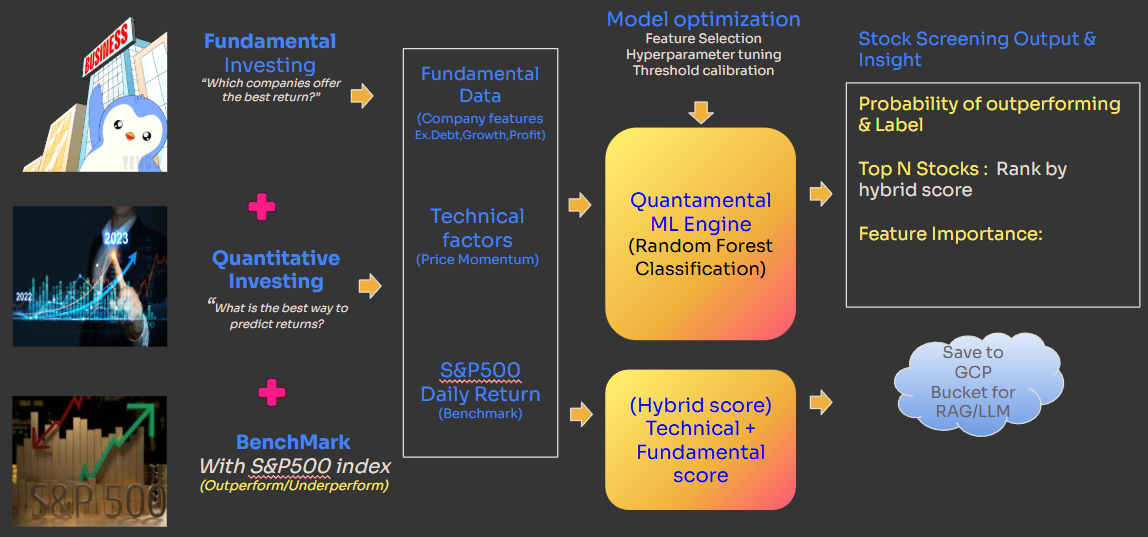

###  Quantamental Model — Simple Explanation

This project combines **finance and machine learning** to help identify which companies are likely to perform better than the market.

We bring together two types of information:

1. **Fundamental data** — these are company features like profit, revenue, debt, and cash flow.  
   They describe how strong or healthy a company is from a business perspective.

2. **Technical data** — these come from stock prices, showing trends and investor behavior.  
   For example, price momentum, volatility, or whether the stock has been moving up or down recently.

To evaluate performance, we also use a **benchmark** — the S&P 500 index — which represents the overall U.S. stock market.  
If a stock performs better than the S&P 500, we say it **outperforms**; if it does worse, it **underperforms**.

---

###  How the Model Works

1. **Data Collection**  
   We collect both *fundamental* and *technical* data for every S&P 500 company.  

2. **Feature Engineering**  
   We process the data to compute useful metrics like growth rates, moving averages, and risk measures.

3. **Machine Learning (Random Forest)**  
   The model learns patterns from historical data — for example, what characteristics were common among stocks that outperformed the S&P 500.

4. **Prediction**  
   The model predicts the **probability** that each stock will outperform in the next month.  
   Stocks with higher probabilities are stronger candidates for investment.

5. **Hybrid Score**  
   We then combine both perspectives:  
   - **Fundamental Score** (long-term business quality)  
   - **Technical Score** (short-term market trend)  
   into one **Hybrid Score** — a balanced indicator of overall potential.

6. **Result**  
   The output ranks all S&P 500 stocks by their hybrid score and provides:
   - A label (Outperform or Underperform)
   - A confidence probability
   - A list of top N recommended stocks  

Finally, results are saved to a **GCP bucket**, where they can be used by an **LLM agent** or **dashboard** for stock screening and explanation.

---

In short:  
> " The Quantamental Model blends *financial fundamentals* and *price trends* with *machine learning* to identify promising stocks — combining long-term quality with short-term momentum."



---
## Finance Data Pipeline


**Update in Milestone 3** 
**Why We Moved Away from yfinance :**

In MS2, we considered using yfinance to download historical market data.
However, we faced two major issues:

- Rate limits: yfinance frequently blocks or throttles requests when fetching data for hundreds of tickers.

- Data quality: Some tickers had missing or inconsistent values, and certain delisted stocks returned incomplete histories.

To address this, we switched to Financial Modeling Prep (FMP) because it provides:

- Reliable OHLCV and fundamental data.

- Both quarterly and annual reports.

- Faster downloads using asynchronous requests (aiohttp).

- .parquet caching for speed and reproducibility.


This change significantly improved data completeness, speed, and reliability for our quantamental pipeline.

**2. Quantamental Model (Random Forest Classification)**
    
- Adding Quantamental Model (which is based on Random forest classification)

**3. Create Hybrid score for Stock ranking**

- Create Hybrid Score which combines the fundamental features and technical features together

The snapshot above demonstrates end to end flow of Quantamental model we plan to implement

In [1]:
#Load Library
import os
import asyncio
import aiohttp
import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
import json



#Set display to prevent jupyter notebook crashed due to large volume of output from API
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)


### Quantamental with Data preparation

**1.Configuration**

We first define the configuration parameters for the pipeline:

- DATA_DIR — local cache directory for data files

- FMP_API_KEY — our Financial Modeling Prep API key

- START and END — define the date range (last 3 years)

- Base API URLs and request headers

In [2]:
# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

FMP_API_KEY = os.environ.get("FMP_API_KEY", "VXTY4Jz8jYbQ9R4PjjkmqJ8VLROXlC3Z")
BASE = "https://financialmodelingprep.com/api/v3"
HEADERS = {"User-Agent": "stockbusters/1.0"}

START = (date.today() - relativedelta(years=3)).isoformat()
END = date.today().isoformat()

print(f"** Pipeline setup complete | Range: {START} → {END}")

** Pipeline setup complete | Range: 2022-11-23 → 2025-11-23


**2. Sorting Helpers**

Before merging datasets, we make sure every record is strictly sorted by symbol and date.
The helper function strict_sort_for_asof() ensures:

- Each stock’s data is in chronological order

- Duplicate or invalid dates are removed

- Non-monotonic time series are automatically fixed

This prevents merge errors when aligning price and fundamentals by time.

In [3]:
# ================================================================
#  SORTING HELPERS Function
# ================================================================

def strict_sort_for_asof(df, sym_col="symbol", date_col="date"):
    """Ensure dataframe is strictly sorted and monotonic within each symbol."""
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[sym_col] = df[sym_col].astype(str)

    df = df.dropna(subset=[sym_col, date_col])
    df = df.drop_duplicates(subset=[sym_col, date_col], keep="last")
    df = df.sort_values([sym_col, date_col], kind="mergesort").reset_index(drop=True)

    bad = df.groupby(sym_col)[date_col].apply(lambda s: (s.diff() < pd.Timedelta(0)).any())
    offenders = bad[bad].index.tolist()
    if offenders:
        print(f"!!! Found {len(offenders)} unsorted symbols — fixing...")
        fixed = [
            g.sort_values(date_col) for _, g in df.groupby(sym_col, sort=False)
        ]
        df = pd.concat(fixed, ignore_index=True)

    return df

**3. Technical Factor Computation**


We calculate key **technical indicators** using the function `add_technical_factors()`.  
These indicators capture **market momentum**, **trend strength**, and **volatility** for each stock.

| **Indicator** | **Description** | **Purpose** |
|----------------|-----------------|--------------|
| **Return (1 month)** | % change over 21 trading days | Measures short-term price momentum |
| **EMA 12 / EMA 26** | Exponential Moving Averages | Smooths price trends to highlight direction |
| **MACD** | `EMA(12) − EMA(26)` | Identifies bullish or bearish momentum shifts |
| **RSI (14)** | Relative Strength Index | Detects overbought or oversold market conditions |
| **Volatility (21d)** | Rolling standard deviation of daily returns | Acts as a proxy for price risk or uncertainty |

Each metric is computed **per symbol** using grouped transformations to ensure every stock is processed independently.  
Small missing values are **forward-filled** to maintain feature continuity for machine learning models.

In [4]:
# ================================================================
#  TECHNICAL FACTORS CALCULATION (updated fixed error)
# ================================================================

#def add_technical_factors(df: pd.DataFrame) -> pd.DataFrame:
def compute_technicals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute key technical indicators per symbol, ensuring alignment:
      - 1M and 1D returns
      - EMA(12), EMA(26), MACD, MACD signal & histogram
      - RSI(14)
      - 21D volatility (rolling std of daily returns)
    """
    # Ensure sorted by symbol/date
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
    g = df.groupby("symbol", group_keys=False)

    # --- Returns ---
    df["return_1m"] = g["close"].transform(lambda x: x.pct_change(21))
    df["return_1d"] = g["close"].transform(lambda x: x.pct_change(1))

    # --- EMAs & MACD ---
    df["ema_12"] = g["close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    df["ema_26"] = g["close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df["macd"] = df["ema_12"] - df["ema_26"]
    df["macd_signal"] = g["macd"].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df["macd_hist"] = df["macd"] - df["macd_signal"]

    # --- RSI (14-day) ---
    delta = g["close"].transform(lambda x: x.diff())
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = g["symbol"].transform(lambda x: gain.rolling(14, min_periods=5).mean())
    avg_loss = g["symbol"].transform(lambda x: loss.rolling(14, min_periods=5).mean())
    rs = avg_gain / (avg_loss + 1e-9)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # --- Volatility (21-day) ---
    df["volatility_21d"] = g["close"].transform(
        lambda x: x.pct_change().rolling(21, min_periods=5).std()
    )

    # --- Fill tail NaNs ---
    df[["RSI_14", "volatility_21d"]] = df.groupby("symbol")[["RSI_14", "volatility_21d"]].ffill()

    return df


**4. Data Fetching with Local Cache**

We retrieve data from FMP in three parts:

-S&P 500 list — via fetch_sp500()

-OHLCV price data — via fetch_ohlcv_all()

-Fundamentals (Quarterly + Annual) — via fetch_fundamentals_combined(), which uses:

-Quarterly data as the default

-Annual data as a fallback for newer companies with limited quarterly history

All results are stored as .parquet files in the data/ directory to prevent repeated API calls.
This design makes the pipeline fast and cost-effective.

In [5]:
# ================================================================
#  FMP FETCHERS WITH LOCAL CACHE
#  Use GenAI to guide coding and create async function
# ================================================================

async def fetch_sp500():
    url = f"{BASE}/sp500_constituent?apikey={FMP_API_KEY}"
    async with aiohttp.ClientSession(headers=HEADERS) as sess:
        async with sess.get(url) as r:
            if r.status != 200:
                raise RuntimeError(f"SP500 fetch failed: HTTP {r.status}")
            js = await r.json()

    tickers = [x["symbol"] for x in js if "symbol" in x]
    print(f"Loaded S&P 500 tickers: {len(tickers)}")
    return tickers



#Fetch OHCLV
async def fetch_ohlcv_symbol(sess, symbol):
    url = f"{BASE}/historical-price-full/{symbol}?from={START}&to={END}&apikey={FMP_API_KEY}"

    async with sess.get(url, timeout=60) as r:
        if r.status != 200:
            print(f"⚠️ OHLCV failed for {symbol}: {r.status}")
            return None
        js = await r.json()

    hist = js.get("historical", [])
    if not hist:
        return None

    df = pd.DataFrame(hist)
    df["symbol"] = symbol
    df["date"] = pd.to_datetime(df["date"])
    return df[["symbol", "date", "open", "high", "low", "close", "adjClose", "volume"]].rename(columns={"adjClose": "adj_close"})


async def fetch_ohlcv_all(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/ohlcv_raw.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached OHLCV data")
        return pd.read_parquet(cache_path)

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        tasks = [fetch_ohlcv_symbol(sess, s) for s in symbols]
        out = []
        for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="OHLCV"):
            try:
                df = await fut
                if df is not None and not df.empty:
                    out.append(df)
            except Exception:
                continue
    df_all = pd.concat(out, ignore_index=True)
    df_all.to_parquet(cache_path, index=False)
    print(f"✅ Saved cache: {cache_path}")
    return df_all

#Fetch Quarterly Key Metrics 
async def fetch_key_metrics_quarterly(sess, symbol):
    url = f"{BASE}/key-metrics/{symbol}?period=quarter&limit=12&apikey={FMP_API_KEY}"
    async with sess.get(url, timeout=30) as r:
        if r.status != 200:
            return None
        js = await r.json()
    if not js:
        return None
    df = pd.DataFrame(js)
    df["symbol"] = symbol
    df["date"] = pd.to_datetime(df["date"])
    return df.dropna(subset=["date"])


# ================================================================
#  COMBINED FUNDAMENTALS FETCHER (Quarterly + Annual fallback)
# This is to use Annual fundamental data when Quarterly data is not exist.
# This helps the company which are part of S&P500 less than 3 years
# ================================================================
async def fetch_fundamentals_combined(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/fundamentals_combined.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached fundamentals (combined)")
        return pd.read_parquet(cache_path)

    async def fetch_key_metrics(sess, symbol, period="quarter"):
        """Helper to fetch either quarterly or annual fundamentals."""
        url = f"{BASE}/key-metrics/{symbol}?period={period}&limit=12&apikey={FMP_API_KEY}"
        async with sess.get(url, timeout=30) as r:
            if r.status != 200:
                return None
            js = await r.json()
        if not js:
            return None
        df = pd.DataFrame(js)
        df["symbol"] = symbol
        df["date"] = pd.to_datetime(df["date"])
        df["period_type"] = period
        return df.dropna(subset=["date"])

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        quarterly_tasks = [fetch_key_metrics(sess, s, "quarter") for s in symbols]
        annual_tasks = [fetch_key_metrics(sess, s, "annual") for s in symbols]

        all_quarterly, all_annual = [], []
        print("📆 Fetching quarterly fundamentals...")
        for fut in tqdm(asyncio.as_completed(quarterly_tasks), total=len(quarterly_tasks)):
            df = await fut
            if df is not None and not df.empty:
                all_quarterly.append(df)

        print("📅 Fetching annual fundamentals (fallback)...")
        for fut in tqdm(asyncio.as_completed(annual_tasks), total=len(annual_tasks)):
            df = await fut
            if df is not None and not df.empty:
                all_annual.append(df)

    # Combine both datasets
    funda_q = pd.concat(all_quarterly, ignore_index=True) if all_quarterly else pd.DataFrame()
    funda_a = pd.concat(all_annual, ignore_index=True) if all_annual else pd.DataFrame()

    print(f"Quarterly fundamentals: {len(funda_q)} rows, Annual fundamentals: {len(funda_a)} rows")

    # Fill missing quarterly data with annual fallback
    combined = pd.concat([funda_q, funda_a], ignore_index=True)
    combined = combined.sort_values(["symbol", "date", "period_type"], ascending=[True, True, False])
    combined = combined.drop_duplicates(subset=["symbol", "date"], keep="first")

    combined.to_parquet(cache_path, index=False)
    print(f"✅ Saved combined fundamentals → {cache_path}")

    return combined

async def fetch_fundamentals_quarterly(symbols, concurrency=8):
    cache_path = f"{DATA_DIR}/fundamentals_quarterly.parquet"
    if os.path.exists(cache_path):
        print("💾 Using cached fundamentals")
        return pd.read_parquet(cache_path)

    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        tasks = [fetch_key_metrics_quarterly(sess, s) for s in symbols]
        out = []
        for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Quarterly Fundamentals"):
            df = await fut
            if df is not None and not df.empty:
                out.append(df)
    df_all = pd.concat(out, ignore_index=True)
    df_all.to_parquet(cache_path, index=False)
    print(f"✅ Saved cache: {cache_path}")
    return df_all

#--- update fetch company profile
async def fetch_company_profile(sess, symbol, max_retries=3):
    url = f"{BASE}/profile/{symbol}?apikey={FMP_API_KEY}"

    for attempt in range(max_retries):
        try:
            async with sess.get(url, timeout=20) as r:
                # Success
                if r.status == 200:
                    js = await r.json()
                    if isinstance(js, list) and len(js) > 0:
                        df = pd.DataFrame(js)
                        df["symbol"] = symbol
                        return df
                    print(f"⚠️ Empty profile for {symbol}")
                    return None

                # Rate limit → retry
                if r.status == 429:
                    wait = (2 ** attempt) + random.uniform(0, 1)
                    print(f"⏳ 429 rate-limit for {symbol}, retrying in {wait:.1f}s...")
                    await asyncio.sleep(wait)
                    continue

                # Other error → give up
                print(f"⚠️ Profile fetch failed for {symbol}: HTTP {r.status}")
                return None

        except Exception as e:
            print(f"⚠️ Exception fetching profile for {symbol}: {e}")
            await asyncio.sleep(1.0)

    print(f"❌ Giving up on {symbol} after {max_retries} retries.")
    return None


####


#Fetch Company profile data from S&P500 list
async def fetch_company_profiles(symbols, force_refresh=False, concurrency=3):
    cache_path = f"{DATA_DIR}/company_profiles.parquet"

    # --------------------------
    # Use cached version if exists
    # --------------------------
    if os.path.exists(cache_path) and not force_refresh:
        print(f"💾 Using cached company profiles → {cache_path}")
        return pd.read_parquet(cache_path)

    # --------------------------
    # Otherwise fetch fresh
    # --------------------------
    print("🌐 Fetching company profiles from FMP...")
    connector = aiohttp.TCPConnector(limit_per_host=concurrency)
    out = []

    async with aiohttp.ClientSession(headers=HEADERS, connector=connector) as sess:
        tasks = [fetch_company_profile(sess, sym) for sym in symbols]

        for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
            df = await fut
            if df is not None and not df.empty:
                out.append(df)

    if not out:
        raise ValueError("❌ No company profiles were fetched. Check API key or FMP rate limits.")

    profiles = pd.concat(out, ignore_index=True)
    profiles.to_parquet(cache_path, index=False)

    print(f"✅ Saved company profiles → {cache_path}")
    print(f"📊 Profiles fetched: {profiles['symbol'].nunique()} symbols")

    return profiles


##



**5.Merge Technicals and Fundamentals**

The main workflow merges both technical and fundamental data using a per-symbol merge_asof() operation.
This method aligns each daily price observation with the most recent quarterly fundamental report.

After merging, small gaps may still exist due to missing report dates or market holidays.
We apply a multi-step cleaning process to ensure the dataset has no NaN or None values:

Forward-fill (ffill) small missing segments per symbol

Back-fill (bfill) early missing values

Median-fill any remaining NaN values per column

Replace infinite values from ratios like PE and PB

Drop rows or symbols with no valid fundamentals

Final NaN removal to make the dataset 100% numeric

After this process, the dataset is completely clean and safe for machine learning.

In [6]:
#to be remove - testing only
import requests

FMP_API_KEY = "VXTY4Jz8jYbQ9R4PjjkmqJ8VLROXlC3Z"   # or use os.environ.get("FMP_API_KEY")

ticker = "AAPL"
url = f"https://financialmodelingprep.com/api/v3/profile/{ticker}?apikey={FMP_API_KEY}"

resp = requests.get(url)
print("Status code:", resp.status_code)
print("Raw response:", resp.text)


Status code: 200
Raw response: [
  {
    "symbol": "AAPL",
    "price": 271.49,
    "beta": 1.109,
    "volAvg": 51066467,
    "mktCap": 4011632075970,
    "lastDiv": 1.03,
    "range": "169.21-277.32",
    "changes": 5.24,
    "companyName": "Apple Inc.",
    "currency": "USD",
    "cik": "0000320193",
    "isin": "US0378331005",
    "cusip": "037833100",
    "exchange": "NASDAQ Global Select",
    "exchangeShortName": "NASDAQ",
    "industry": "Consumer Electronics",
    "website": "https://www.apple.com",
    "description": "Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple TV, Apple Watch, Beats products, and HomePod. It also provides AppleCare support and cloud services; and operates various platforms, including the App St

In [7]:
# ================================================================
#  MAIN WORKFLOW
# ================================================================
async def main(force_refresh=False):
    sp500 = await fetch_sp500()
    print(f"S&P 500 tickers: {len(sp500)}")

    # --- Load OHLCV ---
    if force_refresh and os.path.exists(f"{DATA_DIR}/ohlcv_raw.parquet"):
        os.remove(f"{DATA_DIR}/ohlcv_raw.parquet")
    ohlcv = await fetch_ohlcv_all(sp500)
    print("OHLCV rows:", len(ohlcv))

    # --- Compute technicals ---
    ta_path = f"{DATA_DIR}/ohlcv_with_technicals.parquet"
    if os.path.exists(ta_path):
        print("-> Using cached technicals")
        ohlcv_ta = pd.read_parquet(ta_path)
    else:
        ohlcv_ta = compute_technicals(ohlcv)
        ohlcv_ta.to_parquet(ta_path, index=False)
        print(f"-> Saved {ta_path}")

    # --- Fundamentals ---
    funda_q = await fetch_fundamentals_combined(sp500)
    print("Fundamentals shape:", funda_q.shape)

    # --- Merge ---
    keep_funda = [
        "revenuePerShare", "netIncomePerShare", "operatingCashFlowPerShare",
        "freeCashFlowPerShare", "roe", "roic", "returnOnTangibleAssets",
        "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
        "debtToEquity", "currentRatio", "daysSalesOutstanding",
        "inventoryTurnover", "dividendYield", "payoutRatio"
    ]

    print("-> Starting reliable per-symbol quantamental merge...")
    merged = []
    symbols = sorted(set(ohlcv_ta["symbol"]) & set(funda_q["symbol"]))
    for sym in tqdm(symbols, desc="Merging"):
        left = ohlcv_ta.query("symbol == @sym").sort_values("date")
        right = funda_q.query("symbol == @sym").sort_values("date")
        if len(left) == 0:
            continue
        if len(right) == 0:
            for col in keep_funda:
                left[col] = np.nan
            merged.append(left)
            continue
        m = pd.merge_asof(left, right, on="date", direction="backward", allow_exact_matches=True)
        m[keep_funda] = m[keep_funda].ffill().bfill(limit=1)
        merged.append(m)

    merged = pd.concat(merged, ignore_index=True)
    merged.rename(columns={"symbol_x": "symbol"}, inplace=True)
    merged.drop(columns=["symbol_y"], inplace=True, errors="ignore")

    # --- Drop empty columns ---
    drop_cols = merged.columns[merged.isna().mean() > 0.8]
    if len(drop_cols) > 0:
        print(f"-> Dropping {len(drop_cols)} columns: {list(drop_cols)}")
        merged.drop(columns=drop_cols, inplace=True)

    # ================================================================
    #  POST-MERGE FUNDAMENTAL CLEANUP (FORWARD-FILL)
    # There are small NAN which comes from short gaps of trading holidays and missing update. 
    #  It will be filled by forward filled
    # ================================================================
    print(" Forward-filling short gaps in fundamentals...")

    funda_cols = [
        "revenuePerShare", "netIncomePerShare",
        "operatingCashFlowPerShare", "freeCashFlowPerShare",
        "roe", "roic", "returnOnTangibleAssets",
        "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
        "debtToEquity", "currentRatio",
        "daysSalesOutstanding", "inventoryTurnover",
        "dividendYield", "payoutRatio"
    ]

    # Sort and forward-fill per symbol
    merged = merged.sort_values(["symbol", "date"])
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].ffill(limit=5)

    # Optional: backfill one-step at the start of each symbol
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].bfill(limit=1)

    # Drop any symbol still 100% NaN in fundamentals
    drop_syms = merged.groupby("symbol")[funda_cols].apply(lambda g: g.isna().all().all())
    drop_syms = drop_syms[drop_syms].index.tolist()
    if drop_syms:
        print(f"🗑️ Dropping {len(drop_syms)} symbols with no fundamentals: {drop_syms[:5]}")
        merged = merged[~merged["symbol"].isin(drop_syms)]

    #print("-> Fundamental cleanup complete:", merged.shape)

    # ================================================================
    #  FINAL MODEL-READY CLEANING (NO NaNs)
    # ================================================================
    print("-> Performing final model-ready cleaning...")

    # 1️ Replace inf values (e.g., from PE ratios)
    merged.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 2️ Forward-fill + back-fill fundamentals
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].ffill(limit=60)
    merged[funda_cols] = merged.groupby("symbol")[funda_cols].bfill(limit=2)

    # 3️ Fill remaining NaNs in fundamentals with per-column median
    for col in funda_cols:
        median_val = merged[col].median(skipna=True)
        merged[col] = merged[col].fillna(median_val)

    # 4️ Fill technicals and price columns with safe defaults (avoid None)
    num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        if merged[col].isna().any():
            median_val = merged[col].median(skipna=True)
            merged[col] = merged[col].fillna(median_val)

    # 5️ Drop any row that still contains NaN or None (edge case protection)
    before = len(merged)
    merged = merged.dropna(how="any").reset_index(drop=True)
    after = len(merged)
    if before != after:
        print(f"-> Dropped {before - after} residual rows with NaN/None values")

    # 6️ Verify final cleanliness
    nulls = merged.isna().sum().sum()
    if nulls == 0:
        print("-> All NaNs and None removed. Dataset 100% clean for modeling.")
    else:
        print(f"-> {nulls} NaNs remain — investigate specific columns.")

    # ================================================================
    #  SAVE FINAL DATASET
    # ================================================================
    
    output_path = f"{DATA_DIR}/quantamental_cleaned.parquet"
    merged.to_parquet(output_path, index=False)
    print(f"-> Saved cleaned quantamental dataset → {output_path}")

    # ============================
    # Save company profile
    #=============================
    
    print("\n Fetching S&P500 company profile metadata...")

    # Load from cache or fetch fresh
    profiles = await fetch_company_profiles(sp500)

    profile_path = f"{DATA_DIR}/company_profiles.parquet"
    profiles.to_parquet(profile_path, index=False)

    print(f"-> Saved company profiles → {profile_path}")

    # === Save as CSV  ===
    profile_path_csv = f"{DATA_DIR}/company_profiles.csv"
    profiles.to_csv(profile_path_csv, index=False)
    print(f"-> Saved company profiles (CSV) → {profile_path_csv}")

    



In [8]:
#test to be deleted

import requests

url = f"https://financialmodelingprep.com/api/v3/profile/LOW?apikey={FMP_API_KEY}"
resp = requests.get(url)
print(resp.json())

[{'symbol': 'LOW', 'price': 234.29, 'beta': 0.957, 'volAvg': 2847057, 'mktCap': 131395666992, 'lastDiv': 4.7, 'range': '206.39-280.64', 'changes': 5.86, 'companyName': "Lowe's Companies, Inc.", 'currency': 'USD', 'cik': '0000060667', 'isin': 'US5486611073', 'cusip': '548661107', 'exchange': 'New York Stock Exchange', 'exchangeShortName': 'NYSE', 'industry': 'Home Improvement', 'website': 'https://www.lowes.com', 'description': "Lowe's Companies, Inc., together with its subsidiaries, operates as a home improvement retailer in the United States and internationally. The company offers a line of products for construction, maintenance, repair, remodeling, and decorating. It provides home improvement products, such as appliances, seasonal and outdoor living, lawn and garden, lumber, kitchens and bath, tools, paint, millwork, hardware, flooring, rough plumbing, building materials, decor, lighting, and electrical. It also offers installation services through independent contractors in various 

**7.Validation and Quality Check**

We run a final validation function validate_quantamental() to confirm the integrity of the dataset:

- Displays row counts and number of unique tickers

- Reports missing value percentages per feature

- Plots the coverage distribution by symbol

- Filters out low-coverage tickers automatically

- Saves both .parquet and .csv versions for downstream modeling

This validation step ensures that the final data is uniform and ready for modeling.


In [9]:
################################
# Quantamental data validation
################################

def validate_quantamental(df, keep_funda, coverage_threshold_ratio=0.9, auto_filter=True):
    print(" VALIDATING QUANTAMENTAL DATASET...")
    print(f"Total rows: {len(df):,}")
    print(f"Unique symbols: {df['symbol'].nunique()}")

    nan_stats = (
        df[keep_funda].isna().mean().sort_values(ascending=False).mul(100).round(2)
    )
    print("\nList stock with high Missing Value % (Top 15):")
    print(nan_stats.head(15))

    coverage = df.groupby("symbol")["date"].count().sort_values()
    median_rows = coverage.median()
    threshold = median_rows * coverage_threshold_ratio

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(coverage)), coverage.values)
    plt.title("Rows per Symbol (Coverage Distribution)")
    plt.xlabel("Symbol Index")
    plt.ylabel("Row Count")
    plt.grid(alpha=0.3)
    plt.show()

    low_cov = coverage[coverage < threshold]
    if len(low_cov) > 0:
        print(f" {len(low_cov)} low-coverage symbols found. It will be removed")
        df = df[~df["symbol"].isin(low_cov.index)]
        print(f"✅ Filtered dataset: {df['symbol'].nunique()} symbols remain.")

    df.to_parquet(f"{DATA_DIR}/quantamental_filtered.parquet", index=False)
    print("📁 Saved → quantamental_filtered.parquet")
    df.to_csv(f"{DATA_DIR}/quantamental_filtered.csv", index=False)

    return df


Loaded S&P 500 tickers: 503
S&P 500 tickers: 503
💾 Using cached OHLCV data
OHLCV rows: 376750
-> Using cached technicals
💾 Using cached fundamentals (combined)
Fundamentals shape: (6205, 62)
-> Starting reliable per-symbol quantamental merge...


Merging: 100%|██████████| 390/390 [00:03<00:00, 102.84it/s]


 Forward-filling short gaps in fundamentals...
-> Performing final model-ready cleaning...
-> Dropped 1776 residual rows with NaN/None values
-> All NaNs and None removed. Dataset 100% clean for modeling.
-> Saved cleaned quantamental dataset → ./data/quantamental_cleaned.parquet

 Fetching S&P500 company profile metadata...
💾 Using cached company profiles → ./data/company_profiles.parquet
-> Saved company profiles → ./data/company_profiles.parquet
-> Saved company profiles (CSV) → ./data/company_profiles.csv
 VALIDATING QUANTAMENTAL DATASET...
Total rows: 289,794
Unique symbols: 390

List stock with high Missing Value % (Top 15):
revenuePerShare              0.0
netIncomePerShare            0.0
operatingCashFlowPerShare    0.0
freeCashFlowPerShare         0.0
roe                          0.0
roic                         0.0
returnOnTangibleAssets       0.0
peRatio                      0.0
pbRatio                      0.0
priceToSalesRatio            0.0
pfcfRatio                    0.

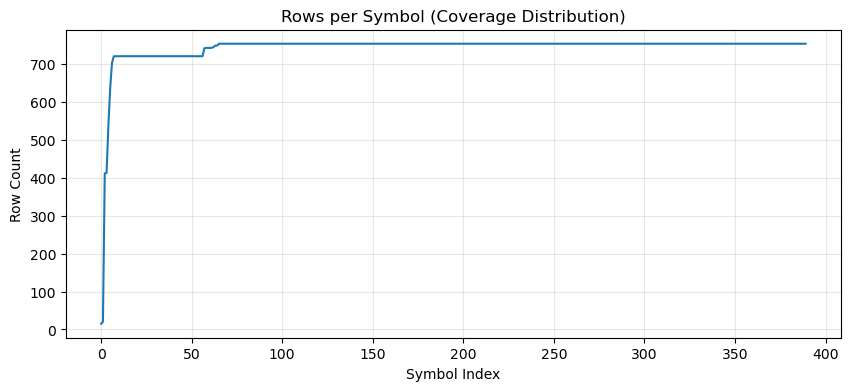

 6 low-coverage symbols found. It will be removed
✅ Filtered dataset: 384 symbols remain.
📁 Saved → quantamental_filtered.parquet


In [10]:
#########################################
# Run everything and show validation
#########################################

try:
    asyncio.get_running_loop()
    import nest_asyncio
    nest_asyncio.apply()
    await main(force_refresh=False)
except RuntimeError:
    asyncio.run(main(force_refresh=False))

df = pd.read_parquet(f"{DATA_DIR}/quantamental_cleaned.parquet")
df = validate_quantamental(df, [
    "revenuePerShare", "netIncomePerShare", "operatingCashFlowPerShare",
    "freeCashFlowPerShare", "roe", "roic", "returnOnTangibleAssets",
    "peRatio", "pbRatio", "priceToSalesRatio", "pfcfRatio",
    "debtToEquity", "currentRatio", "daysSalesOutstanding",
    "inventoryTurnover", "dividendYield", "payoutRatio"
])


In [11]:
#Fetch S&P500 for benchmarking 

async def fetch_sp500_index():
    url = f"{BASE}/historical-price-full/%5EGSPC?from={START}&to={END}&apikey={FMP_API_KEY}"
    async with aiohttp.ClientSession(headers=HEADERS) as sess:
        async with sess.get(url, timeout=30) as r:
            js = await r.json()
    df = pd.DataFrame(js["historical"])
    df["symbol"] = "^GSPC"
    df["date"] = pd.to_datetime(df["date"])
    df = df[["date", "open", "high", "low", "close", "adjClose", "volume"]]
    df.rename(columns={"adjClose": "adj_close"}, inplace=True)
    df["return_1d"] = df["close"].pct_change().round(3)
    return df.sort_values("date")

sp500_index = await fetch_sp500_index()
sp500_index.to_parquet(f"{DATA_DIR}/sp500_index.parquet", index=False)
sp500_index.to_csv(f"{DATA_DIR}/sp500_index.csv", index=False)
print(f"-> Saved S&P 500 index benchmark → {DATA_DIR}/sp500_index.csv")
print(f"-> Saved S&P 500 index benchmark → {DATA_DIR}/sp500_index.parquet")

-> Saved S&P 500 index benchmark → ./data/sp500_index.csv
-> Saved S&P 500 index benchmark → ./data/sp500_index.parquet


In [12]:
# Load the parquet file into a DataFrame , inspect the final result
df1 = pd.read_parquet("./data/quantamental_cleaned.parquet")


# Show first few rows and all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


df1.head(5)


,symbol,date,open,high,low,close,adj_close,volume,return_1m,return_1d,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d,calendarYear,period,revenuePerShare,netIncomePerShare,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,interestDebtPerShare,marketCap,enterpriseValue,peRatio,priceToSalesRatio,pocfratio,pfcfRatio,pbRatio,ptbRatio,evToSales,enterpriseValueOverEBITDA,evToOperatingCashFlow,evToFreeCashFlow,earningsYield,freeCashFlowYield,debtToEquity,debtToAssets,netDebtToEBITDA,currentRatio,interestCoverage,incomeQuality,dividendYield,payoutRatio,salesGeneralAndAdministrativeToRevenue,researchAndDdevelopementToRevenue,intangiblesToTotalAssets,capexToOperatingCashFlow,capexToRevenue,capexToDepreciation,stockBasedCompensationToRevenue,grahamNumber,roic,returnOnTangibleAssets,grahamNetNet,workingCapital,tangibleAssetValue,netCurrentAssetValue,investedCapital,averageReceivables,averagePayables,averageInventory,daysSalesOutstanding,daysPayablesOutstanding,daysOfInventoryOnHand,receivablesTurnover,payablesTurnover,inventoryTurnover,roe,capexPerShare,period_type
0,A,2022-11-14,149.01,149.71,146.30,146.38,143.19,1220300,0.009238,0.000704,146.380000,146.380000,0.000000,0.000000,0.000000,52.158273,0.01528,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
1,A,2022-11-15,148.27,149.46,146.50,148.00,144.78,1299334,0.009238,0.011067,146.629231,146.500000,0.129231,0.025846,0.103385,52.158273,0.01528,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
2,A,2022-11-16,148.19,148.75,146.35,147.12,143.92,1476733,0.009238,-0.005946,146.704734,146.545926,0.158808,0.052438,0.106369,52.158273,0.01528,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter
3,A,2022-11-17,145.33,145.56,142.16,144.44,141.29,1465186,0.009238,-0.018216,146.356313,146.389931,-0.033618,0.035227,-0.068845,52.158273,0.01528,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.82038,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.00923,0.52196,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.15625,0.037858,0.958904,0.014062,22.390622,0.043751,0.0639,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,

## Quantamental Baseline model training (Random Forest)

This section builds the **baseline quantamental model**, which combines both **fundamental** and **technical** features to predict whether a stock will **outperform or underperform** the S&P 500 index in the following month.

### ⚙️ Objective
The goal is to train a supervised machine learning model that can classify each stock as:
- **1 → Outperforming** the S&P 500 (positive alpha)
- **0 → Underperforming** the S&P 500

We use a **Random Forest Classifier**, which is robust to nonlinear relationships and can automatically identify the most important features while minimizing overfitting.

---

### 📦 Step-by-Step Workflow

#### **1. Load Data**
- Load the cleaned quantamental dataset (`quantamental_cleaned.parquet`) and S&P 500 index prices (`sp500_index.csv`).
- Merge the benchmark to compute the S&P 500’s 1-month return (`sp500_return_1m`).

#### **2. Monthly Snapshot**
- Aggregate data at the **monthly level** using the last trading day for each stock.
- This aligns quarterly fundamentals and daily technicals into consistent monthly observations.

#### **3. Define Features**
- **Technical Factors:** momentum, moving averages, MACD, RSI, and volatility indicators.
- **Fundamental Factors:** profitability, valuation, liquidity, efficiency, and growth ratios.

The Random Forest will automatically determine which features matter most and can drop irrelevant ones.

#### **4. Label Creation**
- Compute each stock’s **1-month forward return**.
- Compare it to the S&P 500’s 1-month return to generate the target label:
  - `1` → Stock outperformed the S&P 500
  - `0` → Stock underperformed the S&P 500

#### **5. Lagging Technical Features**
- Lag each technical feature by one period (`_lag1`) to avoid **data leakage** — ensuring the model only uses past data to predict the future.

#### **6. Train/Test Split**
- Train on data from **Sep 2024 – Sep 2025**.
- Test on **Oct 2025** to simulate real-world, out-of-sample prediction.

#### **7. Model Training**
- Standardize all features using `StandardScaler`.
- Train a **Random Forest Classifier** with:
  - 400 estimators
  - Maximum depth of 8
  - Class weights balanced for label imbalance

#### **8. Evaluation Metrics**
- **Accuracy:** overall correct predictions
- **Precision:** ratio of correctly predicted outperformers
- **Recall:** how many real outperformers were identified
- **AUC:** ability to separate outperformers vs. underperformers

#### **9. Feature Importance**
- Extract and visualize the top 25 most important features.
- Save full importances to CSV for deeper financial interpretation.

---

### 🧾 Expected Outcome
- Performance metrics (Accuracy, Precision, Recall, AUC) for the Oct 2025 test month.  
- Ranked list of the top technical and fundamental drivers identified by Random Forest.  
- This baseline serves as a benchmark for more advanced versions such as:
  - Rolling 12-month training windows
  - Hybrid Quantamental Scoring
  - LLM-based interpretability (RAG pipeline)


C:\Users\siris\AppData\Local\Temp\ipykernel_8824\4079292881.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_8824\4079292881.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])


Train rows: 5044, Test rows: 388

=== Evaluation: Oct 2025 Test Month ===
Accuracy=0.513  Precision=0.325  Recall=0.283  AUC=0.464

=== Top 25 Feature Importances ===
                            Feature  Importance
7               volatility_21d_lag1      0.0439
5                    macd_hist_lag1      0.0435
0                    return_1m_lag1      0.0401
6                       RSI_14_lag1      0.0355
4                  macd_signal_lag1      0.0323
3                         macd_lag1      0.0303
38                      payoutRatio      0.0269
2                       ema_26_lag1      0.0241
1                       ema_12_lag1      0.0240
12                     cashPerShare      0.0208
41         intangiblesToTotalAssets      0.0191
37                    dividendYield      0.0159
55                  averagePayables      0.0159
36                    incomeQuality      0.0159
45  stockBasedCompensationToRevenue      0.0155
19                          peRatio      0.0153
10        operati

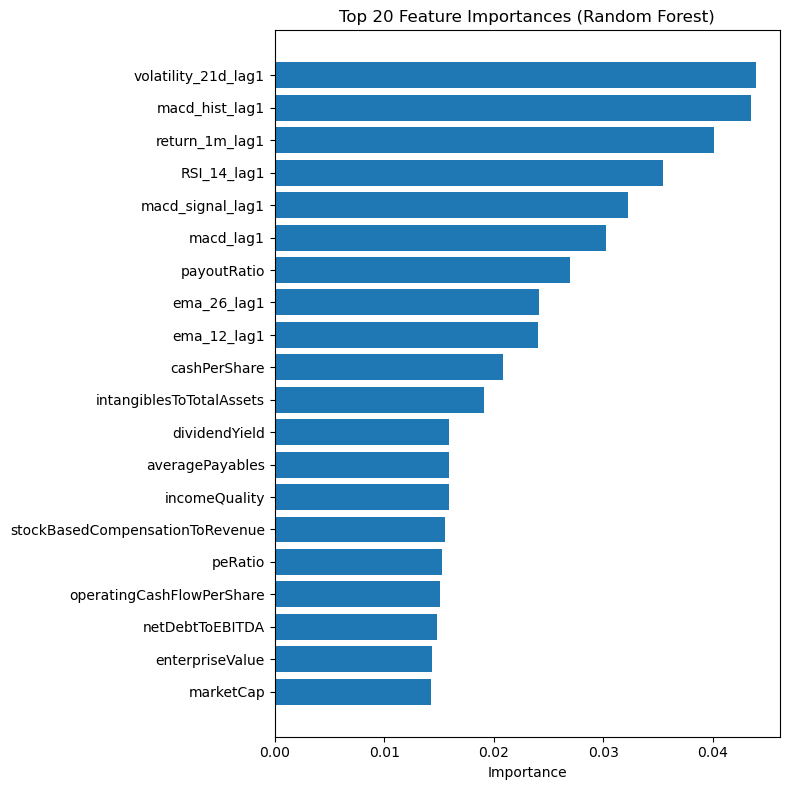

In [13]:
#Baseline Model - include all features and let RF dropped less important features based on feature importance


# =====================================
# LOAD DATA
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURES
# =====================================
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [
    "revenuePerShare","netIncomePerShare","operatingCashFlowPerShare","freeCashFlowPerShare",
    "cashPerShare","bookValuePerShare","tangibleBookValuePerShare","shareholdersEquityPerShare",
    "interestDebtPerShare","marketCap","enterpriseValue","peRatio","priceToSalesRatio","pocfratio",
    "pfcfRatio","pbRatio","ptbRatio","evToSales","enterpriseValueOverEBITDA","evToOperatingCashFlow",
    "evToFreeCashFlow","earningsYield","freeCashFlowYield","debtToEquity","debtToAssets","netDebtToEBITDA",
    "currentRatio","interestCoverage","incomeQuality","dividendYield","payoutRatio",
    "salesGeneralAndAdministrativeToRevenue","researchAndDdevelopementToRevenue",
    "intangiblesToTotalAssets","capexToOperatingCashFlow","capexToRevenue","capexToDepreciation",
    "stockBasedCompensationToRevenue","grahamNumber","roic","returnOnTangibleAssets","grahamNetNet",
    "workingCapital","tangibleAssetValue","netCurrentAssetValue","investedCapital",
    "averageReceivables","averagePayables","averageInventory","daysSalesOutstanding",
    "daysPayablesOutstanding","daysOfInventoryOnHand","receivablesTurnover","payablesTurnover",
    "inventoryTurnover","roe","capexPerShare"
]

# Forward-fill fundamentals to handle quarterly updates
df_monthly[fundamental_cols] = df_monthly.groupby("symbol")[fundamental_cols].ffill()

# =====================================
# LABEL GENERATION
# =====================================
df_monthly["fwd_return_1m"] = df_monthly.groupby("symbol")["close"].shift(-1)/df_monthly["close"] - 1
df_monthly["fwd_sp500_return_1m"] = df_monthly["sp500_return_1m"].shift(-1)
df_monthly["label"] = (df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]).astype(int)

# =====================================
# LAG TECHNICALS TO AVOID LEAKAGE
# =====================================
for col in technical_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

feature_names = [f"{col}_lag1" for col in technical_cols] + fundamental_cols
df_model = df_monthly.dropna(subset=feature_names + ["label", "symbol"])

# =====================================
# TRAIN/TEST SPLIT (Sep 2024–Sep 2025 vs Oct 2025)
# =====================================
train_start, train_end = pd.Timestamp("2024-09-01"), pd.Timestamp("2025-09-30")
test_start, test_end = pd.Timestamp("2025-10-01"), pd.Timestamp("2025-10-31")

train_mask = (df_model["date"] >= train_start) & (df_model["date"] <= train_end)
test_mask  = (df_model["date"] >= test_start) & (df_model["date"] <= test_end)
df_train, df_test = df_model.loc[train_mask], df_model.loc[test_mask]

print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

# =====================================
# TRAIN MODEL
# =====================================
X_train, y_train = df_train[feature_names], df_train["label"]
X_test, y_test   = df_test[feature_names],  df_test["label"]

X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0).fillna(0)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42,class_weight="balanced")
rf.fit(X_train_s, y_train)

# =====================================
# EVALUATION
# =====================================
y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print(f"\n=== Evaluation: Oct 2025 Test Month ===")
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  AUC={auc:.3f}")

# =====================================
# FEATURE IMPORTANCE
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

# Show top 25 most important features
print("\n=== Top 25 Feature Importances ===")
print(importances.head(25).round(4))

# Save all importances to CSV for later review
importances.to_csv("feature_importance_full.csv", index=False)

# Plot top 20
plt.figure(figsize=(8,8))
top_n = importances.head(20)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


We will only select features which are matter in this case and retrain model. Features name are included in the next step and retrain model


C:\Users\siris\AppData\Local\Temp\ipykernel_8824\498238243.py:15: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_8824\498238243.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])


Train rows: 5044, Test rows: 388

=== Evaluation: Oct 2025 Test Month ===
Accuracy=0.500  Precision=0.291  Recall=0.234  AUC=0.468

=== Top 10 Predicted Outperformers for Oct 2025 ===
      symbol       date  pred_prob  label
13617    WDC 2025-10-31      0.716      1
11941    STX 2025-10-31      0.676      0
7135    INTC 2025-10-31      0.673      0
5751     FOX 2025-10-31      0.639      0
8379    LRCX 2025-10-31      0.639      0
6066      GM 2025-10-31      0.639      1
4433    DLTR 2025-10-31      0.636      1
8416    LULU 2025-10-31      0.634      0
1647    AXON 2025-10-31      0.632      0
5788    FOXA 2025-10-31      0.632      0

=== Top 20 Feature Importances ===
                      Feature  Importance
7         volatility_21d_lag1      0.0627
0              return_1m_lag1      0.0550
5              macd_hist_lag1      0.0545
6                 RSI_14_lag1      0.0492
9                cashPerShare      0.0432
4            macd_signal_lag1      0.0420
8                 payout

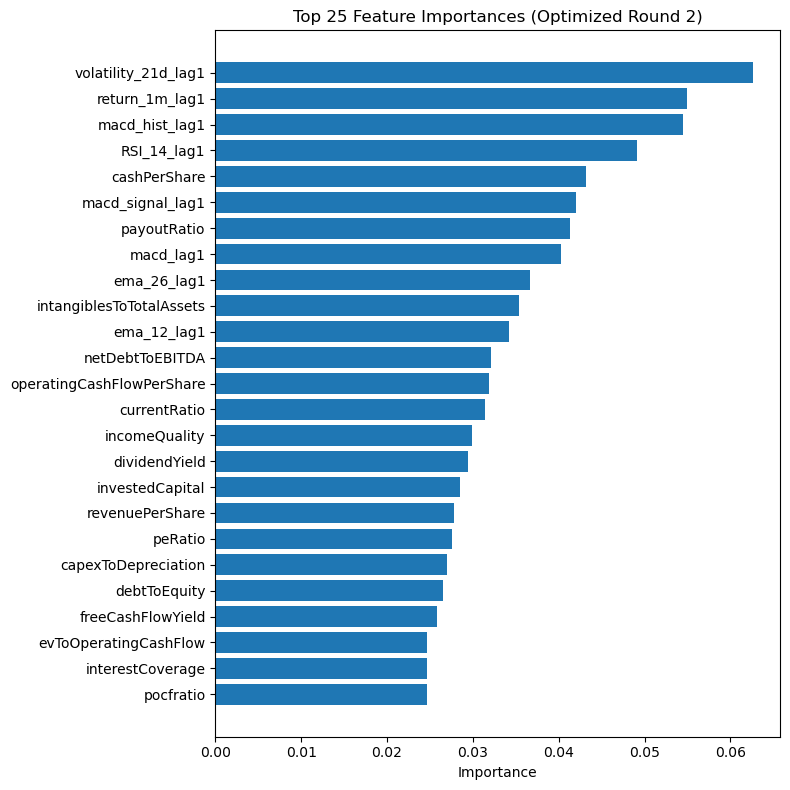

In [14]:

# =====================================
# LOAD DATA (LATEST )
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURE SETS  (based on previous step outcome)
# =====================================
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    # core additions ,we add this features as it is an important features for finance
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# =====================================
# CREATE LAGGED TECHNICAL FEATURES
# =====================================
for col in technical_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

lagged_tech_features = [f"{col}_lag1" for col in technical_cols]

# =====================================
# FORWARD-FILL FUNDAMENTALS
# =====================================
df_monthly[fundamental_cols] = df_monthly.groupby("symbol")[fundamental_cols].ffill()

# =====================================
# FINAL FEATURE LIST
# =====================================
feature_names = lagged_tech_features + fundamental_cols

# Drop rows missing any of the key features
df_monthly = df_monthly.dropna(subset=feature_names)

# =====================================
# CREATE LABEL
# =====================================
df_monthly["fwd_return_1m"] = df_monthly.groupby("symbol")["close"].shift(-1)/df_monthly["close"] - 1
df_monthly["fwd_sp500_return_1m"] = df_monthly["sp500_return_1m"].shift(-1)
df_monthly["label"] = (df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]).astype(int)

# =====================================
# TRAIN/TEST WINDOW (Sep 2024 → Sep 2025 train, Oct 2025 test)
# =====================================
train_start, train_end = pd.Timestamp("2024-09-01"), pd.Timestamp("2025-09-30")
test_start, test_end = pd.Timestamp("2025-10-01"), pd.Timestamp("2025-10-31")

train_mask = (df_monthly["date"] >= train_start) & (df_monthly["date"] <= train_end)
test_mask  = (df_monthly["date"] >= test_start) & (df_monthly["date"] <= test_end)
df_train, df_test = df_monthly.loc[train_mask], df_monthly.loc[test_mask]

print(f"Train rows: {len(df_train)}, Test rows: {len(df_test)}")

# =====================================
# PREPARE DATA
# =====================================
X_train, y_train = df_train[feature_names], df_train["label"]
X_test, y_test   = df_test[feature_names],  df_test["label"]

X_train = X_train.replace([np.inf, -np.inf], 0).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], 0).fillna(0)

scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

# =====================================
# TRAIN RANDOM FOREST (balanced)
# =====================================
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=8,
    class_weight="balanced_subsample",
    random_state=42
)
rf.fit(X_train_s, y_train)

# =====================================
# EVALUATE MODEL
# =====================================
y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)

print(f"\n=== Evaluation: Oct 2025 Test Month ===")
print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  AUC={auc:.3f}")

# =====================================
# TOP-10 PREDICTED OUTPERFORMERS
# =====================================
df_test = df_test.copy()
df_test["pred_prob"] = y_prob
df_test["pred_label"] = y_pred

top10 = (
    df_test.sort_values("pred_prob", ascending=False)
            .head(10)[["symbol","date","pred_prob","label"]]
)
print("\n=== Top 10 Predicted Outperformers for Oct 2025 ===")
print(top10.round(3))

# =====================================
# FEATURE IMPORTANCE
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== Top 20 Feature Importances ===")
print(importances.head(20).round(4))

# =====================================
# VISUALIZE FEATURE IMPORTANCE
# =====================================
plt.figure(figsize=(8,8))
top_n = importances.head(25)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 25 Feature Importances (Optimized Round 2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


This chart shows the top 25 most important features that the Random Forest model relied on to predict whether a stock would outperform or underperform the S&P 500.

From the results, technical indicators dominate — especially MACD Signal, MACD Histogram, and 1-month return, suggesting that short-term momentum and trend signals have the strongest influence on the model’s predictions.
Meanwhile, fundamental ratios such as payout ratio, current ratio, and cash per share contribute less but still provide long-term financial stability context for the model’s decisions.

In [15]:
print(df_train["label"].value_counts(normalize=True))


label
0    0.558089
1    0.441911
Name: proportion, dtype: float64


The outperform/underperform label are balanced

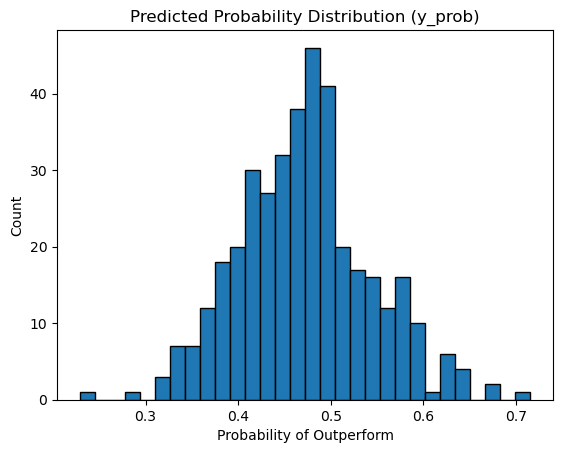

Min: 0.22862974896606958 Max: 0.7158516136673838 Mean: 0.47160533606535465


In [16]:
#Display the predicted probability distribution

plt.hist(y_prob, bins=30, edgecolor='k')
plt.title("Predicted Probability Distribution (y_prob)")
plt.xlabel("Probability of Outperform")
plt.ylabel("Count")
plt.show()

print("Min:", y_prob.min(), "Max:", y_prob.max(), "Mean:", y_prob.mean())


This histogram shows the distribution of predicted probabilities from the Random Forest model — specifically, how confident the model is that each stock will outperform the S&P 500.

Most probabilities cluster around 0.3–0.6, meaning the model is generally uncertain and sees a roughly even balance between outperformers and underperformers.
The mean (~0.46) suggests that, on average, the model predicts a slightly higher chance of underperformance.

We use this plot to choose a cutoff threshold — for example, selecting a value (like 0.5 or one optimized for F1-score) that best separates likely outperformers (high probability) from likely underperformers (low probability). This threshold determines which stocks receive a “Buy” or “Avoid” signal in the final output.

We will repeat the step with the adjust cut off threshold based on this chart

C:\Users\siris\AppData\Local\Temp\ipykernel_8824\3553615116.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["sp500_return_1m"] = df["sp500_close"].pct_change(21)
C:\Users\siris\AppData\Local\Temp\ipykernel_8824\3553615116.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
C:\Users\siris\AppData\Local\Temp\ipykernel_8824\3553615116.py:56: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="date", freq="M"))["sp500_close"]



Label distribution (all data):
label
0    0.662
1    0.338
Name: proportion, dtype: float64
2023-11 | Thresh=0.447 | Acc=0.468 Prec=0.335 Rec=0.792 AUC=0.614
2024-01 | Thresh=0.383 | Acc=0.482 Prec=0.461 Rec=0.959 AUC=0.585
2024-02 | Thresh=0.301 | Acc=0.307 Prec=0.298 Rec=0.991 AUC=0.524
2024-04 | Thresh=0.313 | Acc=0.381 Prec=0.374 Rec=0.993 AUC=0.491
2024-05 | Thresh=0.523 | Acc=0.678 Prec=0.163 Rec=0.476 AUC=0.587
2024-07 | Thresh=0.333 | Acc=0.521 Prec=0.518 Rec=0.995 AUC=0.431


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2024-08 | Thresh=0.284 | Acc=0.003 Prec=0.000 Rec=0.000 AUC=nan
2024-09 | Thresh=0.260 | Acc=0.521 Prec=0.519 Rec=0.995 AUC=0.477
2024-10 | Thresh=0.359 | Acc=0.564 Prec=0.565 Rec=0.995 AUC=0.640


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2024-11 | Thresh=0.297 | Acc=0.003 Prec=0.000 Rec=0.000 AUC=nan
2024-12 | Thresh=0.320 | Acc=0.544 Prec=0.544 Rec=0.995 AUC=0.580
2025-01 | Thresh=0.260 | Acc=0.564 Prec=0.565 Rec=0.995 AUC=0.505
2025-02 | Thresh=0.334 | Acc=0.593 Prec=0.594 Rec=0.996 AUC=0.433
2025-03 | Thresh=0.327 | Acc=0.430 Prec=0.424 Rec=0.994 AUC=0.407
2025-04 | Thresh=0.406 | Acc=0.415 Prec=0.392 Rec=0.946 AUC=0.548


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2025-05 | Thresh=0.360 | Acc=0.003 Prec=0.000 Rec=0.000 AUC=nan
2025-06 | Thresh=0.371 | Acc=0.428 Prec=0.424 Rec=0.994 AUC=0.484
2025-07 | Thresh=0.371 | Acc=0.528 Prec=0.530 Rec=0.995 AUC=0.425


c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\siris\micromamba\micromamba\envs\cs109b_gpu\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


2025-08 | Thresh=0.356 | Acc=0.003 Prec=0.000 Rec=0.000 AUC=nan
2025-09 | Thresh=0.366 | Acc=0.289 Prec=0.286 Rec=0.991 AUC=0.479
2025-10 | Thresh=0.372 | Acc=0.329 Prec=0.324 Rec=0.992 AUC=0.541

=== Rolling 12-Month Evaluation Summary ===
       Threshold  Accuracy  Precision  Recall     AUC
count     21.000    21.000     21.000  21.000  17.000
mean       0.350     0.384      0.348   0.766   0.515
std        0.061     0.212      0.205   0.399   0.070
min        0.260     0.003      0.000   0.000   0.407
25%        0.313     0.307      0.286   0.792   0.477
50%        0.356     0.430      0.392   0.992   0.505
75%        0.371     0.528      0.519   0.995   0.580
max        0.523     0.678      0.594   0.996   0.640

Top Feature Importance:
                       Feature  Importance
7         volatility_21d_lag1      0.0889
5              macd_hist_lag1      0.0819
0              return_1m_lag1      0.0771
3                   macd_lag1      0.0539
4            macd_signal_lag1      0.

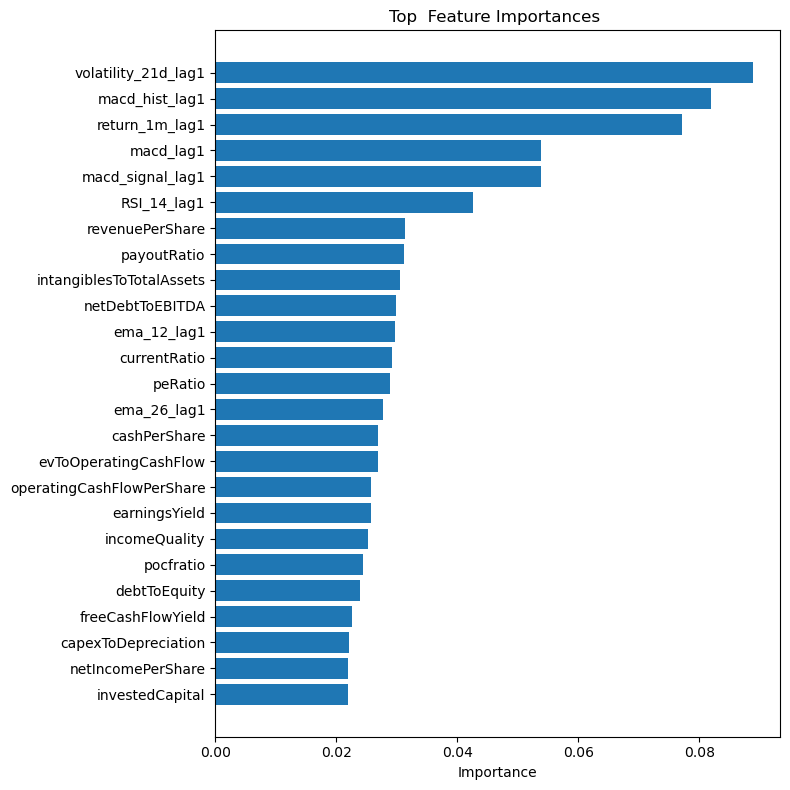

In [17]:
# Adjust cut off threshold

# =====================================
# LOAD DATA
# =====================================
df = pd.read_parquet("./data/quantamental_cleaned.parquet")
sp500 = pd.read_csv("./data/sp500_index.csv")

df["date"] = pd.to_datetime(df["date"])
sp500["date"] = pd.to_datetime(sp500["date"])
df = df.sort_values(["symbol", "date"])
sp500 = sp500.sort_values("date")

# Merge S&P500 benchmark
sp500 = sp500.rename(columns={"close": "sp500_close"})
df = pd.merge(df, sp500[["date", "sp500_close"]], on="date", how="left")
df["sp500_return_1m"] = df["sp500_close"].pct_change(21)

# =====================================
# CREATE MONTHLY SNAPSHOT
# =====================================
df_monthly = (
    df.groupby(["symbol", pd.Grouper(key="date", freq="M")])
      .tail(1)
      .reset_index(drop=True)
)

# =====================================
# DEFINE FEATURE SETS
# =====================================
tech_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fund_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    # core additions
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# Forward-fill fundamentals (quarterly)
#fund_cols = ["roe", "peRatio", "freeCashFlowYield", "debtToEquity", "currentRatio", "dividendYield"]
df_monthly[fund_cols] = df_monthly.groupby("symbol")[fund_cols].ffill()


# =====================================
# CREATE FORWARD-LOOKING LABEL
# (align S&P returns properly per month)
# =====================================

# 1️⃣ Compute S&P500 monthly closes (end-of-month)
spm = (
    df.groupby(pd.Grouper(key="date", freq="M"))["sp500_close"]
      .last()
      .reset_index()
      .rename(columns={"sp500_close": "sp500_close_curr"})
)
spm["sp500_close_next"] = spm["sp500_close_curr"].shift(-1)
spm["fwd_sp500_return_1m"] = spm["sp500_close_next"] / spm["sp500_close_curr"] - 1

# 2️⃣ Merge monthly S&P forward return back into df_monthly
df_monthly = df_monthly.merge(
    spm[["date", "fwd_sp500_return_1m"]],
    on="date", how="left"
)

# 3️⃣ Compute stock forward return aligned by symbol
df_monthly["fwd_return_1m"] = (
    df_monthly.groupby("symbol")["close"].shift(-1) / df_monthly["close"] - 1
)

# 4️⃣ Label: 1 if stock beats S&P next month
df_monthly["label"] = (
    df_monthly["fwd_return_1m"] > df_monthly["fwd_sp500_return_1m"]
).astype(int)

# ✅ Check label balance
print("\nLabel distribution (all data):")
print(df_monthly["label"].value_counts(normalize=True).round(3))





# =====================================
# LAG TECHNICAL INDICATORS (prevent leakage)
# =====================================
#tech_cols = ["return_1m", "macd_hist", "RSI_14", "volatility_21d"]
for col in tech_cols:
    df_monthly[f"{col}_lag1"] = df_monthly.groupby("symbol")[col].shift(1)

# =====================================
# FINAL FEATURE SET
# =====================================
feature_names = [f"{col}_lag1" for col in tech_cols] + fund_cols
df_model = df_monthly.dropna(subset=feature_names + ["label"])

# =====================================
# ROLLING 12-MONTH TRAIN/TEST LOOP
# =====================================
all_results = []

start_date = df_model["date"].min() + relativedelta(months=11)
end_date = df_model["date"].max()



while start_date < end_date:
    # Define rolling window (11M train + 1M test)
    train_start = start_date - relativedelta(months=11)
    train_end = start_date
    test_start = start_date
    test_end = start_date + relativedelta(months=1)

    train_mask = (df_model["date"] >= train_start) & (df_model["date"] < train_end)
    test_mask = (df_model["date"] >= test_start) & (df_model["date"] < test_end)

    df_train = df_model.loc[train_mask]
    df_test = df_model.loc[test_mask]

    if len(df_train) < 100 or len(df_test) < 10:
        start_date += relativedelta(months=1)
        continue

    X_train, y_train = df_train[feature_names], df_train["label"]
    X_test, y_test = df_test[feature_names], df_test["label"]

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model (with class balancing)
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, class_weight="balanced", random_state=42)
    rf.fit(X_train_scaled, y_train)

    # Predict probabilities
    y_prob = rf.predict_proba(X_test_scaled)[:, 1]

    # =====================================
    # AUTO-THRESHOLD USING F1 OPTIMIZATION
    # =====================================
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if len(thresholds) > 0 else 0.5

    y_pred = (y_prob > best_thresh).astype(int)

    # Evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    all_results.append({
        "Test_Month": test_start.strftime("%Y-%m"),
        "Train_Start": train_start.strftime("%Y-%m"),
        "Train_End": train_end.strftime("%Y-%m"),
        "Threshold": round(best_thresh, 3),
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "AUC": round(auc, 3)
    })

    print(f"{test_start:%Y-%m} | Thresh={best_thresh:.3f} | Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} AUC={auc:.3f}")

    start_date += relativedelta(months=1)

# =====================================
# SUMMARY OF ROLLING RESULTS
# =====================================
results_df = pd.DataFrame(all_results)
print("\n=== Rolling 12-Month Evaluation Summary ===")
print(results_df.describe().round(3))

# =====================================
# FEATURE IMPORTANCE (last model)
# =====================================
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Feature Importance:\n", importances.head(25).round(4))


# =====================================
# VISUALIZE FEATURE IMPORTANCE
# =====================================
plt.figure(figsize=(8,8))
top_n = importances.head(25)
plt.barh(top_n["Feature"], top_n["Importance"])
plt.gca().invert_yaxis()
plt.title("Top  Feature Importances ")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



In [18]:
# =====================================
# FINAL MODEL: PREDICT LAST MONTH FOR TESTING 
# =====================================
print("\n=== Final Quantamental Prediction: october 2025 ===")

# 1️⃣ Define training and test windows
test_month = pd.Timestamp("2025-10-01")
train_start = test_month - relativedelta(months=12)
train_end = test_month - relativedelta(days=1)

df_train = df_model[(df_model["date"] >= train_start) & (df_model["date"] < train_end)]
df_test  = df_model[(df_model["date"].dt.to_period("M") == test_month.to_period("M"))]

if len(df_test) == 0:
    print("No data for Oct 2025.")
else:
    # 2️⃣ Prepare features
    X_train, y_train = df_train[feature_names], df_train["label"]
    X_test = df_test[feature_names]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3️⃣ Train model
    rf_final = RandomForestClassifier(n_estimators=400, max_depth=8, class_weight="balanced", random_state=42)
    rf_final.fit(X_train_scaled, y_train)

    # 4️⃣ Predict probabilities
    y_prob = rf_final.predict_proba(X_test_scaled)[:, 1]

    # 5️⃣ Find optimal F1 threshold
    

    y_val_prob = rf_final.predict_proba(X_train_scaled)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_train, y_val_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx] if len(thresholds) > 0 else 0.5

    y_pred = (y_prob > best_thresh).astype(int)

    # 6️⃣ Attach predictions to DataFrame
    df_test["pred_prob"] = y_prob
    df_test["pred_label"] = y_pred

    # 7️⃣ Rank Top 10 Outperformers
    top10 = df_test.sort_values("pred_prob", ascending=False).head(10)[["symbol", "date", "pred_prob", "label"]]
    print("\nTop 10 predicted outperformers for Oct 2025:")
    print(top10.to_string(index=False))

    # 8️⃣ Summary metrics
    acc  = accuracy_score(df_test["label"], df_test["pred_label"])
    prec = precision_score(df_test["label"], df_test["pred_label"], zero_division=0)
    rec  = recall_score(df_test["label"], df_test["pred_label"], zero_division=0)
    auc  = roc_auc_score(df_test["label"], df_test["pred_prob"])
    print(f"\nOct 2025 Metrics | Thresh={best_thresh:.3f} | Acc={acc:.3f} Prec={prec:.3f} Rec={rec:.3f} AUC={auc:.3f}")

    # 9️⃣ Save to CSV (optional)
    output_path = "./data/results_oct2025_predictions.csv"
    df_test[["symbol", "date", "pred_prob", "pred_label", "label"]].to_csv(output_path, index=False)
    print(f"\nPredictions saved to {output_path}")



=== Final Quantamental Prediction: october 2025 ===

Top 10 predicted outperformers for Oct 2025:
symbol       date  pred_prob  label
   UHS 2025-10-31   0.646172      1
   MPC 2025-10-31   0.644465      1
   STX 2025-10-31   0.628007      1
   WDC 2025-10-31   0.624702      1
   HCA 2025-10-31   0.610498      1
  DLTR 2025-10-31   0.608040      1
   CAT 2025-10-31   0.605772      0
    GM 2025-10-31   0.602848      1
    EW 2025-10-31   0.590396      1
   LHX 2025-10-31   0.588552      1

Oct 2025 Metrics | Thresh=0.490 | Acc=0.510 Prec=0.676 Rec=0.466 AUC=0.564

Predictions saved to ./data/results_oct2025_predictions.csv


C:\Users\siris\AppData\Local\Temp\ipykernel_8824\3652972770.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["pred_prob"] = y_prob
C:\Users\siris\AppData\Local\Temp\ipykernel_8824\3652972770.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["pred_label"] = y_pred


## Predict the next future month

This code uses the most recent 12 months of data (November 2024–2025) to train a Random Forest model, then predicts which stocks are likely to outperform in December 2025 — even though the real outcomes (ground truth) are not yet known.

It scales the features, trains the model, and outputs each stock’s probability of outperforming the S&P 500 next month.
The results are ranked by predicted probability, and the Top 10 highest-ranked stocks are listed as the most likely outperformers for November 2025.

**Step Description :**

1️	Train on the last 12 months of known history

2️	Use October 2025 features (latest available)

3️	Predict which stocks will beat S&P in November 2025

4️	Generate a ranked list of buy candidates (pred_prob_next_month)

5️	No accuracy/recall computed — because ground truth isn’t available yet

In [19]:



print("\n=== PREDICTING NEXT MONTH (Dec 2025, no ground truth yet) ===")

# Define windows
predict_month = pd.Timestamp("2025-12-01")
train_start = predict_month - relativedelta(months=12)
train_end = predict_month - relativedelta(days=1)

# Train on previous 12 months (Nov 2024–nov 2025)
df_train = df_model[(df_model["date"] >= train_start) & (df_model["date"] <= train_end)]

# Predict for current/latest available month (Dec 2025 features)
latest_period = df_model["date"].dt.to_period("M").max()
df_predict = df_model[df_model["date"].dt.to_period("M") == latest_period].copy()


# Prepare data
X_train = df_train[feature_names]
y_train = df_train["label"]
X_pred = df_predict[feature_names]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_pred_scaled = scaler.transform(X_pred)

# Train model
rf_deploy = RandomForestClassifier(
    n_estimators=400, max_depth=8, class_weight="balanced", random_state=42
)
rf_deploy.fit(X_train_scaled, y_train)

# Predict probability of outperforming
pred_prob = rf_deploy.predict_proba(X_pred_scaled)[:, 1]

df_predict["pred_prob_next_month"] = pred_prob
df_predict["pred_rank"] = df_predict["pred_prob_next_month"].rank(ascending=False)

# Rank top 10 expected outperformers for Dec 2025
top10_next = df_predict.sort_values("pred_prob_next_month", ascending=False).head(10)[
    ["symbol", "date", "pred_prob_next_month"]
]
print("\nTop 10 Predicted Outperformers for Dec 2025 (No Ground Truth):")
print(top10_next.to_string(index=False))

# Optional: save
df_predict[["symbol", "date", "pred_prob_next_month", "pred_rank"]].to_csv(
    "./predictions_dec2025.csv", index=False
)
print("\nPredictions saved to ./predictions_dec2025.csv")



=== PREDICTING NEXT MONTH (Dec 2025, no ground truth yet) ===

Top 10 Predicted Outperformers for Dec 2025 (No Ground Truth):
symbol       date  pred_prob_next_month
   UHS 2025-11-14              0.591448
   MPC 2025-11-14              0.574916
   BAC 2025-11-14              0.557381
   HCA 2025-11-14              0.549519
    MS 2025-11-14              0.546752
  HSIC 2025-11-14              0.542255
   XOM 2025-11-14              0.538399
   PHM 2025-11-14              0.537132
   AES 2025-11-14              0.536485
  TSCO 2025-11-14              0.536003

Predictions saved to ./predictions_dec2025.csv


In [20]:
X_pred.head()

,return_1m_lag1,ema_12_lag1,ema_26_lag1,macd_lag1,macd_signal_lag1,macd_hist_lag1,RSI_14_lag1,volatility_21d_lag1,payoutRatio,cashPerShare,dividendYield,revenuePerShare,earningsYield,evToOperatingCashFlow,netDebtToEBITDA,freeCashFlowYield,pocfratio,intangiblesToTotalAssets,netIncomePerShare,incomeQuality,capexToDepreciation,operatingCashFlowPerShare,peRatio,returnOnTangibleAssets,investedCapital,roe,roic,debtToEquity,currentRatio,interestCoverage
36,0.055227,144.063968,140.198226,3.865742,4.280823,-0.415082,72.372042,0.013280,0.211310,5.385965,0.002170,6.098246,0.010269,95.565884,4.021459,0.017512,90.389088,0.404384,1.178947,1.077381,2.930556,1.270175,24.345871,0.046141,9.271000e+09,0.052747,0.031799,0.535165,2.247886,12.857143
73,0.051491,264.225564,257.929709,6.295855,5.302713,0.993142,80.532401,0.015068,0.137675,3.659029,0.004038,27.839649,0.029332,34.961535,0.545867,0.025864,34.254353,0.000000,7.493060,0.995286,1.086938,7.457738,34.092883,0.311796,4.336500e+10,1.519130,0.519684,1.524107,0.893293,0.000000
110,-0.078289,226.631018,226.253837,0.377181,1.921235,-1.544054,29.661579,0.012547,2.577139,3.140192,0.035072,31.845110,0.013609,20.029156,4.179544,0.056726,16.715479,0.703043,2.418315,4.387774,0.116146,10.630865,73.480902,0.106585,8.699100e+10,1.286617,0.102102,20.403308,0.660198,3.253917
145,0.041567,126.338580,125.240715,1.097864,0.843566,0.254298,70.983607,0.012130,0.000000,18.849338,0.000000,6.586572,0.018201,51.772991,-3.210814,0.017963,55.670484,0.033515,2.210000,0.986900,0.000000,2.181048,13.735294,0.061639,6.544000e+09,0.159582,0.112349,0.264576,1.391695,0.000000
182,-0.070456,126.794272,128.934026,-2.139754,-1.600690,-0.539065,28.774617,0.010880,0.627682,0.000000,0.004405,6.500286,0.007018,0.000000,0.000000,0.000000,0.000000,0.000000,0.939966,0.000000,0.000000,0.000000,35.623641,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,46.136364


This code below converts the model’s predicted probabilities into trading signals for December 2025.

Stocks with a predicted probability above 0.40 are labeled “LONG-Outperform” (buy signal).

Stocks with a probability below 0.35 are labeled “SHORT-Underperform” (sell or avoid signal).

Others are marked as “NEUTRAL.”

It then sorts all predictions from highest to lowest probability, displays the top 5 long and short candidates, and saves the full list (with signals and probabilities) to signals_dec2025.csv for portfolio or dashboard use.

In [21]:
# =====================================
# SIGNAL GENERATION (LONG (buy) / SHORT)
# =====================================
prod_threshold = 0.50  # or results_df["Threshold"].mean() if already defined

df_predict["signal"] = np.where(
    df_predict["pred_prob_next_month"] > prod_threshold, "LONG-Outperform",
    np.where(df_predict["pred_prob_next_month"] < (prod_threshold - 0.05), "SHORT-Underperform", "NEUTRAL")
)

# Sort full dataframe by probability (high → low)
df_predict = df_predict.sort_values("pred_prob_next_month", ascending=False).reset_index(drop=True)

# Show distribution of signals
print("\nSignal Distribution:")
print(df_predict["signal"].value_counts())

# Display Top N LONG and SHORT signals
top_long = df_predict[df_predict["signal"] == "LONG-Outperform"].head(5)
top_short = df_predict[df_predict["signal"] == "SHORT-Underperform"].tail(5)  # tail since low probs now at bottom

print("\n=== Top 5 LONG (Buy) Signals for Dec 2025 ===")
print(top_long[["symbol", "pred_prob_next_month","signal"]])

print("\n=== Top 5 SHORT (Sell/Avoid) Signals for Dec 2025 ===")
print(top_short[["symbol", "pred_prob_next_month","signal"]])

# Save for dashboard/portfolio (sorted by probability)
output_path = "./signals_dec2025.csv"
df_predict[["symbol", "date", "pred_prob_next_month", "signal"]].to_csv(output_path, index=False)
print(f"\nSignals saved (sorted high→low) to {output_path}")



Signal Distribution:
signal
SHORT-Underperform    202
NEUTRAL               143
LONG-Outperform        45
Name: count, dtype: int64

=== Top 5 LONG (Buy) Signals for Dec 2025 ===
  symbol  pred_prob_next_month           signal
0    UHS              0.591448  LONG-Outperform
1    MPC              0.574916  LONG-Outperform
2    BAC              0.557381  LONG-Outperform
3    HCA              0.549519  LONG-Outperform
4     MS              0.546752  LONG-Outperform

=== Top 5 SHORT (Sell/Avoid) Signals for Dec 2025 ===
    symbol  pred_prob_next_month              signal
385   ISRG              0.251287  SHORT-Underperform
386    APP              0.243012  SHORT-Underperform
387    VST              0.241747  SHORT-Underperform
388   AVGO              0.231158  SHORT-Underperform
389   CHRW              0.229182  SHORT-Underperform

Signals saved (sorted high→low) to ./signals_dec2025.csv


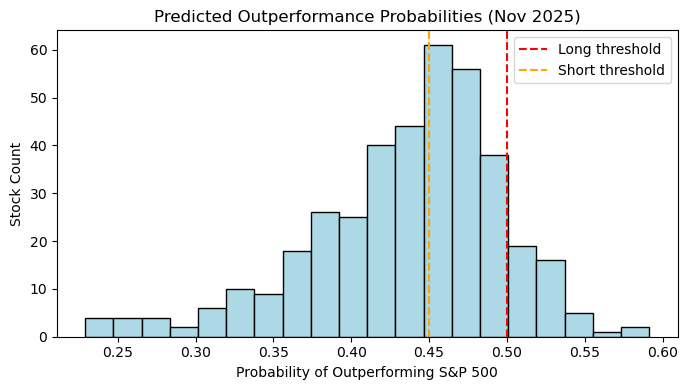

In [22]:
plt.figure(figsize=(7,4))
plt.hist(df_predict["pred_prob_next_month"], bins=20, color='lightblue', edgecolor='k')
plt.axvline(prod_threshold, color='red', linestyle='--', label='Long threshold')
plt.axvline(prod_threshold - 0.05, color='orange', linestyle='--', label='Short threshold')
plt.title("Predicted Outperformance Probabilities (Nov 2025)")
plt.xlabel("Probability of Outperforming S&P 500")
plt.ylabel("Stock Count")
plt.legend()
plt.tight_layout()
plt.show()


**Strategy Mapping - Signal	Interpretation	 Action**

**LONG**	Model believes the stock will outperform S&P500 next month	Add to buy list or overweight

**NEUTRAL**	No strong conviction	Hold or ignore

**SHORT**	Model expects underperformance	Avoid / hedge / underweight

## Create Hybrid score

###  Why We Need a Hybrid Quantamental Score

In stock analysis, there are two main perspectives:

| Perspective | Focus | Limitation |
|--------------|--------|-------------|
| **Fundamental Analysis** | Measures a company’s real business strength — profits, debt, cash flow, valuation, etc. | Changes slowly and may miss short-term market signals |
| **Technical Analysis** | Measures market sentiment and price momentum — how traders are behaving right now | Ignores company fundamentals and can overreact to noise |

A **Hybrid Quantamental Score** combines both perspectives into one interpretable measure.  
This approach is called *quantamental investing*, meaning **quantitative + fundamental** —  
using data-driven signals to evaluate both company strength and market behavior at once.

We use this score incorporate with the outcome of stock signal prediction in order to help user making decision. Long Term user should rely more on the quality of the company which reflects in the Fundamental Analysis. Short term user benefits more on Technical Analysis and the outcome of the Random forest classifier output. 

---

##  Purpose of Fundamental and Technical Scores

- **Fundamental Score** → tells us how financially strong or undervalued a company is  
  (based on metrics like ROE, PE Ratio, Free Cash Flow Yield, Debt/Equity, etc.)

- **Technical Score** → tells us how the stock is performing in the market  
  (based on metrics like MACD, RSI, Monthly Return, and Volatility)

By calculating both, we can:
- Identify **quality companies** (good fundamentals)
- That also show **positive market momentum** (good technicals)

These are often the most promising stocks — “**good companies getting better.**”

---

##  What the Code Does

This section of the notebook calculates three new scores for each stock:

1. **Fundamental_Score**
   - Uses financial ratios such as ROE, PE Ratio, Free Cash Flow Yield, Debt to Equity, and more.
   - Each feature is **normalized between 0 and 1** using Min–Max scaling, so they are comparable.
   - Features where **lower is better** (like PE or Debt/Equity) are **inverted** first,  
     so that higher values always mean better performance.
   - Then we take the **average of all normalized fundamental features** to get a single score per stock.

2. **Technical_Score**
   - Uses indicators such as monthly return, MACD, RSI, and volatility.
   - Also normalized to 0–1 so that all features contribute equally.
   - Volatility is inverted so that **lower volatility = higher technical score**.
   - Then we average them to get a single technical momentum score.

3. **Hybrid_Score**
   - Combines both scores:
     \[
     \text{Hybrid\_Score} = 0.5 \times \text{Fundamental\_Score} + 0.5 \times \text{Technical\_Score}
     \]
   - It is possible to adjust the weights:
     - More **short-term focus** → 70% technical, 30% fundamental  
     - More **long-term focus** → 70% fundamental, 30% technical

4. **Hybrid_Rank**
   - Within each month, all stocks are ranked by Hybrid_Score (1 = best performer for that month).
   - This gives a monthly leaderboard of the strongest “quantamental” stocks.

---

##  Summary of What Happens in Code

1. Clean and prepare the data (`NaN`, `inf`, zero replacement).  
2. Invert downside metrics (e.g., 1 / PE Ratio, 1 / Volatility).  
3. Normalize all factors using **Min–Max scaling (0–1)**.  
4. Calculate:
   - `Technical_Score` = average of normalized technical indicators  
   - `Fundamental_Score` = average of normalized fundamental indicators  
   - `Hybrid_Score` = weighted combination of both
5. Rank all stocks each month by their `Hybrid_Score`.
6. Sort and display the top-ranked stocks with the strongest fundamentals *and* momentum.

---

##  Why This Matters

This Hybrid Quantamental Score serves three purposes:
- Makes model results easier to interpret (we can explain “why” a stock scores high)
- Can be used alongside Random Forest predictions to build a combined “AI Quant Score”
- Creates a consistent ranking system for both short-term trading and long-term investing

In short:
> **The Hybrid Score bridges financial health (fundamentals) and market behavior (technicals), giving a complete 360° view of stock strength.**


##  Quantamental Feature Reference Table

This table explains each **technical** and **fundamental** factor used in the Quantamental and Hybrid Score model.  
Each feature captures a specific dimension of company performance or market sentiment.  
Together, they help evaluate whether a stock is fundamentally strong and/or technically bullish.

---

###  Technical Indicators (Market Momentum & Price Action)

| Feature | Description | Used For | Typical Signal | Interpretation |
|----------|--------------|-----------|----------------|----------------|
| **return_1m** | 1-month percentage return of the stock. Measures short-term momentum. | Short-term trading | ↑ High return → **Bullish / Buy**<br>↓ Negative → **Bearish / Sell** | Captures recent strength or weakness vs. S&P500. |
| **ema_12 / ema_26** | 12-day and 26-day *Exponential Moving Averages*. EMA_12 reacts faster than EMA_26. | Short- & mid-term | EMA_12 > EMA_26 → **Bullish**<br>EMA_12 < EMA_26 → **Bearish** | Used to spot trend direction. |
| **macd** | Difference between EMA_12 and EMA_26. Shows momentum strength. | Short-term | ↑ MACD rising → **Bullish**<br>↓ Falling → **Bearish** | Measures acceleration of price trend. |
| **macd_signal** | 9-day EMA of MACD. Used to identify MACD crossovers. | Short-term | MACD > Signal → **Buy**<br>MACD < Signal → **Sell** | Confirms bullish or bearish momentum. |
| **macd_hist** | MACD – MACD Signal. Shows divergence between short-term and mid-term trend. | Short-term | Positive hist → **Bullish**<br>Negative → **Bearish** | Momentum confirmation tool. |
| **RSI_14** | *Relative Strength Index* over 14 days. Measures speed and magnitude of price changes. | Short-term | RSI > 70 → **Overbought / Sell**<br>RSI < 30 → **Oversold / Buy** | Tracks market sentiment extremes. |
| **volatility_21d** | Standard deviation of daily returns over 21 days. Measures risk. | Short-term risk control | ↓ Low volatility → **Stable / Hold**<br>↑ High → **Risky / Sell** | High volatility may indicate uncertainty. |

**Summary:**  
Technical indicators are more relevant for **short-term (1–3 months)** momentum.  
High MACD, positive return_1m, and rising EMAs indicate **bullish** momentum;  
falling RSI and negative MACD suggest **bearish** or weak momentum.

---

###  Fundamental Factors (Financial Quality & Valuation)

| Feature | Description | Used For | Typical Signal | Interpretation |
|----------|--------------|-----------|----------------|----------------|
| **roe (Return on Equity)** | Profitability per unit of shareholder equity. | Long-term | ↑ High → **Buy / Strong fundamentals** | Measures management efficiency. |
| **roic (Return on Invested Capital)** | Profitability after considering debt & equity. | Long-term | ↑ High → **Buy** | Strong indicator of sustainable profitability. |
| **peRatio (Price-to-Earnings)** | How much investors pay per $1 of earnings. | Long-term valuation | ↓ Low → **Value / Buy**<br>↑ High → **Overvalued / Sell** | Measures valuation attractiveness. |
| **payoutRatio** | Portion of earnings paid as dividends. | Long-term | ↑ Moderate → **Stable / Hold**<br>Too high → **Risky / Sell** | Indicates sustainability of dividends. |
| **dividendYield** | Dividend return as % of stock price. | Long-term income | ↑ High → **Income Buy**<br>0 → **Growth stock / Neutral** | Steady dividends suggest mature, stable company. |
| **freeCashFlowYield** | Free cash flow relative to market cap. | Long-term | ↑ High → **Buy** | Reflects real cash profitability. |
| **operatingCashFlowPerShare** | Operating cash generated per share. | Long-term | ↑ High → **Buy / Strong quality** | Indicates cash-generating power. |
| **revenuePerShare** | Revenue per share, a measure of sales productivity. | Long-term growth | ↑ High or growing → **Buy** | Shows scale and demand strength. |
| **earningsYield** | Inverse of PE ratio. | Long-term valuation | ↑ High → **Undervalued / Buy** | Measures earnings return per dollar invested. |
| **debtToEquity** | Financial leverage ratio. | Long-term risk | ↓ Low → **Healthy / Buy**<br>↑ High → **Risky / Sell** | Captures balance sheet risk. |
| **currentRatio** | Current assets ÷ current liabilities. | Long-term liquidity | 1–2 → **Healthy**<br><1 → **Risky** | Indicates short-term solvency. |
| **interestCoverage** | EBIT (Earning before interest/tax) ÷ Interest expense. | Long-term risk | ↑ High → **Safe / Buy**<br>↓ Low → **Debt concern** | Shows ability to service debt. |
| **netDebtToEBITDA** | Debt relative to earnings capacity. | Long-term leverage | ↓ Low → **Safe**<br>↑ High → **Risky** | Used by credit analysts for leverage. |
| **intangiblesToTotalAssets** | Intangibles / total assets. | Long-term stability | ↓ Low → **Stable**<br>↑ High → **Risky** | High values imply weaker tangible asset base. |
| **pocfratio (Price / Operating Cash Flow)** | Valuation ratio alternative to PE. | Long-term valuation | ↓ Low → **Value Buy** | Cash-based valuation metric. |
| **capexToDepreciation** | Measures reinvestment vs asset wear. | Long-term growth | ↑ High → **Growth / Reinvestment** | Indicates investment intensity. |
| **cashPerShare** | Cash holdings per share. | Short-term defense | ↑ High → **Safe** | Provides cushion during downturns. |
| **incomeQuality** | Operating cash flow / Net income. | Long-term quality | ↑ High → **High-quality earnings** | Detects earnings manipulation risk. |
| **evToOperatingCashFlow** | Enterprise value / operating cash flow. | Long-term valuation | ↓ Low → **Value Buy** | Indicates how expensive a stock is relative to its cash flow. |
| **investedCapital** | Total long-term capital used by the firm. | Long-term structural | — | Used in ROIC computation context. |

**Summary:**  
Fundamental indicators describe **long-term health, valuation, and profitability**.  
They’re better suited for investors who hold positions for **6–24 months or longer**.

---



##  Investment Recommendation Based on Hybrid Quantamental Score

### Quantamental Hybrid Scoring Logic (Cross-Sectional Rank Method)

###  Purpose :
Combine **Fundamental** (long-term company strength) and **Technical** (short-term momentum) signals  
into a single, balanced score for smarter and more explainable stock screening.  This is added to compliment the prediction from Random Forest Classification

---

###  How It Works :

1. **Feature Groups**
   - **Technical:** short-term market behavior  
     → `return_1m`, `MACD`, `RSI_14`, `volatility_21d`, `EMA_12`, `EMA_26`
   - **Fundamental:** long-term financial health  
     → `ROE`, `ROIC`, `PE`, `Debt/Equity`, `Free Cash Flow Yield`, `Revenue/Share`

2. **Monthly Normalization**
   - Each feature is ranked **within its month** on a 0–1 percentile scale.  
   - Ensures fair, relative comparison among stocks (removes scale bias).

3. **Subscores**
   - `Technical_Score` = average of all technical feature ranks  
   - `Fundamental_Score` = average of all fundamental feature ranks  

4. **Hybrid Score**
   \[
   \text{Hybrid\_Score} = 0.5 \times \text{Fundamental\_Score} + 0.5 \times \text{Technical\_Score}
   \]

5. **Percentile-Based Classification**
   | Hybrid Percentile | Meaning |
   |--------------------|----------|
   | Top 30% | **Strong (Buy)** |
   | Middle 40% | **Neutral / Hold** |
   | Bottom 30% | **Weak (Avoid)** |

6. **Investment Bias**
   | Logic | Recommendation |
   |--------|----------------|
   | `Technical > Fundamental + 0.05` | 🔵 **Short-Term Buy (Momentum)** |
   | `Fundamental > Technical + 0.05` | 🟢 **Long-Term Buy (Fundamental)** |
   | Similar Strength | 🟡 **Balanced Buy / Hold** |
   | Low Hybrid Score | 🔴 **Avoid / Bearish** |

---

###  Why we think it Works
- **Dynamic:** adjusts every month, highlighting new leaders and laggards  
- **Explainable:** shows *why* a stock is favored (momentum vs fundamentals)  
- **Balanced:** supports both **short-term trading** and **long-term investing**

*** Need to back test and fine tune the threshold in the future ***


In [23]:

# ===========================================
#  HYBRID QUANTAMENTAL SCORE Calculation
# ===========================================

df_score = df_monthly.copy()
df_score.replace([np.inf, -np.inf], np.nan, inplace=True)

#  Define feature groups
tech_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]
fund_cols = [
    "payoutRatio","cashPerShare","dividendYield","revenuePerShare","earningsYield",
    "evToOperatingCashFlow","netDebtToEBITDA","freeCashFlowYield","pocfratio",
    "intangiblesToTotalAssets","netIncomePerShare","incomeQuality","capexToDepreciation",
    "operatingCashFlowPerShare","peRatio","returnOnTangibleAssets","investedCapital",
    "roe","roic","debtToEquity","currentRatio","interestCoverage"
]

# only use columns that exist in your data
tech_cols = [c for c in tech_cols if c in df_score.columns]
fund_cols = [c for c in fund_cols if c in df_score.columns]

#  Define if higher values are better (True) or worse (False)
higher_better = {
    # Technicals
    "return_1m": True, "ema_12": True, "ema_26": True,
    "macd": True, "macd_signal": True, "macd_hist": True,
    "RSI_14": True,  # can flip to False if you want high RSI = overbought
    "volatility_21d": False,
    # Fundamentals
    "payoutRatio": False,
    "cashPerShare": True,
    "dividendYield": True,
    "revenuePerShare": True,
    "earningsYield": True,
    "evToOperatingCashFlow": False,
    "netDebtToEBITDA": False,
    "freeCashFlowYield": True,
    "pocfratio": False,
    "intangiblesToTotalAssets": False,
    "netIncomePerShare": True,
    "incomeQuality": True,
    "capexToDepreciation": True,
    "operatingCashFlowPerShare": True,
    "peRatio": False,
    "returnOnTangibleAssets": True,
    "investedCapital": True,
    "roe": True,
    "roic": True,
    "debtToEquity": False,
    "currentRatio": True,
    "interestCoverage": True,
}

#  Prepare month identifier
df_score["ym"] = df_score["date"].dt.to_period("M")

#--- newly updated section 1 start
def cs_rank(series):
    """
    Cross-sectional percentile rank in [0,1].
    Always: low value → low percentile, high value → high percentile.
    """
    return series.rank(pct=True, ascending=True)

rank_cols = []

all_factor_cols = tech_cols + fund_cols

for col in all_factor_cols:
    if col not in df_score.columns:
        print(f"WARNING: {col} not found in df_score — skipping")
        continue

    # Base percentile: high value = high percentile
    base = (
        df_score
        .groupby("ym")[col]
        .transform(cs_rank)
        .astype(float)
    )

    # If lower is better → flip the percentile
    is_higher_better = higher_better.get(col, True)
    if not is_higher_better:
        base = 1.0 - base

    rank_col = f"{col}_rank"
    df_score[rank_col] = base
    rank_cols.append(rank_col)

print("Finished creating:", len(rank_cols), "rank columns")

#---- newly updated section end

#--newly update2--

# --------------------------------------------
# Build Technical, Fundamental, Hybrid Scores
# --------------------------------------------

# Make lists of the rank columns created in Step 1
tech_rank_cols = [f"{c}_rank" for c in tech_cols if f"{c}_rank" in df_score.columns]
fund_rank_cols = [f"{c}_rank" for c in fund_cols if f"{c}_rank" in df_score.columns]

print("Technical rank columns:", tech_rank_cols)
print("Fundamental rank columns:", fund_rank_cols)

# Technical Score = mean of technical percentiles
df_score["Technical_Score"] = df_score[tech_rank_cols].mean(axis=1, skipna=True)

# Fundamental Score = mean of fundamental percentiles
df_score["Fundamental_Score"] = df_score[fund_rank_cols].mean(axis=1, skipna=True)

# Hybrid Score = even blend
df_score["Hybrid_Score"] = (
    0.5 * df_score["Technical_Score"] +
    0.5 * df_score["Fundamental_Score"]
)

# Cross-sectional percentile of Hybrid Score per month
df_score["Hybrid_CS_Pct"] = (
    df_score
    .groupby("ym")["Hybrid_Score"]
    .transform(lambda s: s.rank(pct=True, ascending=True))
)

#--newly update2 end

#----- new update3 start 
# ---------------------------------------------------------
#  Improved Hybrid Recommendation Logic
# ---------------------------------------------------------
import numpy as np
import pandas as pd

def classify_stock_v2(row,
                      top_cut=0.70,
                      bot_cut=0.30,
                      diff_thresh=0.05,
                      min_ret_1m=0.02,    # minimum +2% momentum
                      min_RSI=50,         # RSI must be bullish
                      min_macd_hist=0.0   # MACD histogram must be positive
                     ):
    """
    Improved logic:
    - Uses Hybrid percentile to choose the main bucket (Top/Middle/Bottom)
    - Uses Technical vs Fundamental difference to choose style
    - Uses ABSOLUTE momentum filters for real momentum buys
    """

    hyb  = row["Hybrid_CS_Pct"]
    diff = row["Technical_Score"] - row["Fundamental_Score"]

    # Extract technical indicators safely
    r1m = row.get("return_1m", np.nan)
    rsi = row.get("RSI_14", np.nan)
    mh  = row.get("macd_hist", np.nan)

    # ---------------------------------------------------------
    # TOP BUCKET = potential BUY categories
    # ---------------------------------------------------------
    if hyb >= top_cut:

        # Momentum Buy: both relative & absolute momentum must confirm
        if (
            (diff > diff_thresh) and
            pd.notna(r1m) and r1m > min_ret_1m and
            pd.notna(rsi) and rsi > min_RSI and
            pd.notna(mh)  and mh > min_macd_hist
        ):
            return "Short-Term Buy (Momentum)"

        # Fundamental Buy
        elif diff < -diff_thresh:
            return "Long-Term Buy (Fundamental)"

        # Solid stock but not strong enough for a Buy call
        else:
            return "Balanced Buy / Hold"

    # ---------------------------------------------------------
    # BOTTOM BUCKET = weak stocks → Avoid
    # ---------------------------------------------------------
    elif hyb <= bot_cut:
        return "Avoid / Bearish"

    # ---------------------------------------------------------
    # MIDDLE BUCKET = Neutral
    # ---------------------------------------------------------
    else:
        return "Hold / Neutral"


# Apply the new classifier
df_score["Recommendation_v2"] = df_score.apply(classify_stock_v2, axis=1)
df_score["H_Score Recommendation"] = df_score["Recommendation_v2"]  # temporary replace 

#--- new update3 end


#  Sort and rank for latest month
latest_month = df_score["ym"].max()
df_latest = (
    df_score[df_score["ym"] == latest_month]
    .sort_values("Hybrid_Score", ascending=False)
    .reset_index(drop=True)
)
df_latest["Hybrid_Rank"] = df_latest["Hybrid_Score"].rank(ascending=False)

#  Display summary
print(f"\n=== Top 15 Stocks by Hybrid Quantamental Score ({latest_month}) ===")
with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(df_latest[[
        "symbol","date","Hybrid_Score","Fundamental_Score",
        "Technical_Score","Hybrid_CS_Pct","H_Score Recommendation"
    ]].head(15))


# Summary distribution
print("\nRecommendation distribution:")
print(df_latest["H_Score Recommendation"].value_counts())

#  Save results
output_path = "./hybrid_scores_ranked_recommendations.csv"
df_latest[[
    "symbol","date","Hybrid_Score","Fundamental_Score","Technical_Score",
    "Hybrid_Rank","Hybrid_CS_Pct","H_Score Recommendation"
]].to_csv(output_path, index=False)

print(f"\n✅ Saved ranked hybrid quantamental scores to: {output_path}")


Finished creating: 30 rank columns
Technical rank columns: ['return_1m_rank', 'ema_12_rank', 'ema_26_rank', 'macd_rank', 'macd_signal_rank', 'macd_hist_rank', 'RSI_14_rank', 'volatility_21d_rank']
Fundamental rank columns: ['payoutRatio_rank', 'cashPerShare_rank', 'dividendYield_rank', 'revenuePerShare_rank', 'earningsYield_rank', 'evToOperatingCashFlow_rank', 'netDebtToEBITDA_rank', 'freeCashFlowYield_rank', 'pocfratio_rank', 'intangiblesToTotalAssets_rank', 'netIncomePerShare_rank', 'incomeQuality_rank', 'capexToDepreciation_rank', 'operatingCashFlowPerShare_rank', 'peRatio_rank', 'returnOnTangibleAssets_rank', 'investedCapital_rank', 'roe_rank', 'roic_rank', 'debtToEquity_rank', 'currentRatio_rank', 'interestCoverage_rank']

=== Top 15 Stocks by Hybrid Quantamental Score (2025-11) ===


,symbol,date,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_CS_Pct,H_Score Recommendation
0,CB,2025-11-14,0.824446,0.785431,0.863462,1.000000,Short-Term Buy (Momentum)
1,REGN,2025-11-14,0.820586,0.768415,0.872756,0.997436,Short-Term Buy (Momentum)
2,BRK-B,2025-11-14,0.784732,0.709207,0.860256,0.994872,Short-Term Buy (Momentum)
3,TRV,2025-11-14,0.765589,0.660023,0.871154,0.992308,Short-Term Buy (Momentum)
4,HCA,2025-11-14,0.746693,0.719347,0.774038,0.989744,Balanced Buy / Hold
5,RL,2025-11-14,0.744027,0.736131,0.751923,0.987179,Balanced Buy / Hold
6,LLY,2025-11-14,0.740501,0.557925,0.923077,0.984615,Short-Term Buy (Momentum)
7,ALL,2025-11-14,0.731920,0.669930,0.793910,0.982051,Short-Term Buy (Momentum)
8,UHS,2025-11-14,0.730376,0.712354,0.748397,0.979487,Balanced Buy / Hold
9,XOM,2025-11-14,0.730303,0.755478,0.705128,0.976923,Long-Term Buy (Fundamental)



Recommendation distribution:
H_Score Recommendation
Hold / Neutral                 155
Avoid / Bearish                117
Short-Term Buy (Momentum)       51
Balanced Buy / Hold             39
Long-Term Buy (Fundamental)     28
Name: count, dtype: int64

✅ Saved ranked hybrid quantamental scores to: ./hybrid_scores_ranked_recommendations.csv


In [24]:
#Merge Quantamental output and Hybrid score together

# Load both outputs

df_ml = pd.read_csv("./signals_dec2025.csv")
df_hybrid = pd.read_csv("./hybrid_scores_ranked_recommendations.csv")

# Ensure consistent column names and formats
df_ml["symbol"] = df_ml["symbol"].str.upper()
df_hybrid["symbol"] = df_hybrid["symbol"].str.upper()

# Merge on symbol (and optionally date if both use same snapshot)
merged_df = pd.merge(
    df_ml,
    df_hybrid,
    on=["symbol"],  # you can add 'date' if both have same timestamp
    how="inner"
)

# Sort by predicted probability and hybrid score
merged_df = merged_df.sort_values(
    by=["pred_prob_next_month", "Hybrid_Score"], ascending=[False, False]
).reset_index(drop=True)

# Display
from IPython.display import display
print("\n=== Combined Quantamental (ML) + Hybrid Factor Scores ===")
with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(merged_df.head(20))

# Save merged output
output_path = "./combined_quantamental_hybrid_scores.csv"
merged_df.to_csv(output_path, index=False)
print(f"\n Merged dataset saved to: {output_path}")



=== Combined Quantamental (ML) + Hybrid Factor Scores ===


,symbol,date_x,pred_prob_next_month,signal,date_y,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_Rank,Hybrid_CS_Pct,H_Score Recommendation
0,UHS,2025-11-14,0.591448,LONG-Outperform,2025-11-14,0.730376,0.712354,0.748397,9.0,0.979487,Balanced Buy / Hold
1,MPC,2025-11-14,0.574916,LONG-Outperform,2025-11-14,0.700743,0.705012,0.696474,13.0,0.969231,Balanced Buy / Hold
2,BAC,2025-11-14,0.557381,LONG-Outperform,2025-11-14,0.488913,0.453147,0.524679,210.0,0.464103,Hold / Neutral
3,HCA,2025-11-14,0.549519,LONG-Outperform,2025-11-14,0.746693,0.719347,0.774038,5.0,0.989744,Balanced Buy / Hold
4,MS,2025-11-14,0.546752,LONG-Outperform,2025-11-14,0.505813,0.380536,0.631090,185.0,0.528205,Hold / Neutral
5,HSIC,2025-11-14,0.542255,LONG-Outperform,2025-11-14,0.598048,0.581352,0.614744,82.5,0.791026,Balanced Buy / Hold
6,XOM,2025-11-14,0.538399,LONG-Outperform,2025-11-14,0.730303,0.755478,0.705128,10.0,0.976923,Long-Term Buy (Fundamental)
7,PHM,2025-11-14,0.537132,LONG-Outperform,2025-11-14,0.630361,0.790210,0.470513,58.0,0.853846,Long-Term Buy (Fundamental)
8,AES,2025-11-14,0.536485,LONG-Outperform,2025-11-14,0.405682,0.488928,0.322436,313.0,0.200000,Avoid / Bearish
9,TSCO,2025-11-14,0.536003,LONG-Outperform,2025-11-14,0.526734,0.580070,0.473397,159.0,0.594872,Hold / Neutral



 Merged dataset saved to: ./combined_quantamental_hybrid_scores.csv


Above is the short version without fundamental/technical detail

This code below merges all final outputs — the Quantamental ML predictions, Hybrid scores, and the latest technical + fundamental factors — into one unified dataset for analysis or dashboarding.

**Here’s what it does step-by-step:**

Loads model results: Reads the ML predictions (signals_dec2025.csv) and Hybrid scores (hybrid_scores_ranked_recommendations.csv), then merges them by stock symbol.

Prepares monthly data: Filters the latest month (e.g., Oct 2025) from df_monthly and ensures all stocks have data by backfilling missing ones.

Selects core features: Keeps key fundamental and technical indicators used in the model.

Combines everything: Merges the ML, hybrid, and factor datasets into a single table.

Sorts & displays: Orders by highest predicted outperform probability and hybrid score, showing the top 15 ranked stocks.

Saves results: Exports a clean, aligned dataset (combined_quantamental_hybrid_with_factors.csv) for further visualization or portfolio use.

In [25]:


# ============================================
# 1️ Load ML and Hybrid outputs
# ============================================

df_ml = pd.read_csv("./signals_dec2025.csv")
df_hybrid = pd.read_csv("./hybrid_scores_ranked_recommendations.csv")

df_ml["symbol"] = df_ml["symbol"].str.upper()
df_hybrid["symbol"] = df_hybrid["symbol"].str.upper()

# Merge Quantamental ML + Hybrid
merged_df = pd.merge(df_ml, df_hybrid, on="symbol", how="inner", suffixes=("_ml", "_hyb"))

# Drop redundant date columns if exist
merged_df.drop(columns=[c for c in merged_df.columns if c.startswith("date_")], inplace=True, errors="ignore")

# ============================================
# 2️ Prepare aligned monthly factors
# ============================================

df_monthly["date"] = pd.to_datetime(df_monthly["date"])
df_monthly["ym"] = df_monthly["date"].dt.to_period("M")

# Determine the *latest common month* in the dataset
latest_month = df_monthly["ym"].max()
print(f"\nUsing latest available month: {latest_month}")

# Filter only that month
df_latest_month = df_monthly[df_monthly["ym"] == latest_month].copy()

#  If some stocks missing, backfill from previous month
# get the most recent record before latest_month
if df_latest_month["symbol"].nunique() < df_monthly["symbol"].nunique():
    missing_symbols = set(df_monthly["symbol"].unique()) - set(df_latest_month["symbol"].unique())
    fallback = (
        df_monthly[df_monthly["symbol"].isin(missing_symbols)]
        .groupby("symbol")
        .tail(1)
    )
    df_latest_month = pd.concat([df_latest_month, fallback], ignore_index=True)

# ============================================
# 3️ Select feature columns
# ============================================

fundamental_cols = [
    "roe","roic","peRatio","freeCashFlowYield","debtToEquity","currentRatio",
    "dividendYield","earningsYield","payoutRatio","cashPerShare","revenuePerShare"
]
technical_cols = [
    "return_1m","ema_12","ema_26","macd","macd_signal","macd_hist","RSI_14","volatility_21d"
]

fundamental_cols = [c for c in fundamental_cols if c in df_latest_month.columns]
technical_cols = [c for c in technical_cols if c in df_latest_month.columns]

df_factors = df_latest_month[["symbol", "date"] + fundamental_cols + technical_cols].copy()

# ============================================
# 4️ Merge all together
# ============================================

df_full = pd.merge(merged_df, df_factors, on="symbol", how="left")

# ============================================
# 5️ Sort & Display
# ============================================

df_full = df_full.sort_values(by=["pred_prob_next_month", "Hybrid_Score"], ascending=[False, False]).reset_index(drop=True)

print(f"\n=== Combined Quantamental + Hybrid score + Aligned Monthly Factors ({latest_month}) ===")
with pd.option_context('display.max_columns', None, 'display.width', 3000):
    display(df_full.head(15))

# ============================================
# 6️ Save clean output
# ============================================

output_path = "./data/combined_quantamental_hybrid_with_factors.csv"
df_full.to_csv(output_path, index=False)
print(f"\n✅ Saved aligned factor dataset to: {output_path}")



Using latest available month: 2025-11

=== Combined Quantamental + Hybrid score + Aligned Monthly Factors (2025-11) ===


,symbol,pred_prob_next_month,signal,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_Rank,Hybrid_CS_Pct,H_Score Recommendation,date,roe,roic,peRatio,freeCashFlowYield,debtToEquity,currentRatio,dividendYield,earningsYield,payoutRatio,cashPerShare,revenuePerShare,return_1m,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d
0,UHS,0.591448,LONG-Outperform,0.730376,0.712354,0.748397,9.0,0.979487,Balanced Buy / Hold,2025-11-14,0.171326,0.105534,10.455433,0.094069,0.743366,1.274104,0.004467,0.095644,0.046709,1.892944,237.820942,0.114473,224.024355,217.501697,6.522659,6.596511,-0.073852,64.106290,0.015550
1,MPC,0.574916,LONG-Outperform,0.700743,0.705012,0.696474,13.0,0.969231,Balanced Buy / Hold,2025-11-14,0.194139,0.072588,13.808273,0.128906,1.620626,1.173813,0.024259,0.072420,0.334978,9.413490,407.225806,0.109440,195.089918,192.480775,2.609144,2.096478,0.512666,54.784713,0.023155
2,BAC,0.557381,LONG-Outperform,0.488913,0.453147,0.524679,210.0,0.464103,Hold / Neutral,2025-11-14,0.027845,0.006810,11.370024,0.121697,2.327034,0.413761,0.006363,0.021988,0.289408,128.274846,6.458746,0.045004,53.060884,52.487882,0.573002,0.648821,-0.075818,47.313691,0.011291
3,HCA,0.549519,LONG-Outperform,0.746693,0.719347,0.774038,5.0,0.989744,Balanced Buy / Hold,2025-11-14,-2.304922,0.166836,13.475641,0.072649,-18.102041,1.081505,0.008889,0.074208,0.119792,7.815068,273.016941,0.137011,467.174274,455.101390,12.072884,12.451651,-0.378767,56.744118,0.016597
4,MS,0.546752,LONG-Outperform,0.505813,0.380536,0.631090,185.0,0.528205,Hold / Neutral,2025-11-14,0.041924,0.007670,13.542633,-0.061784,3.770612,0.257415,0.006827,0.018460,0.369848,65.594526,19.852960,0.026559,164.825646,162.783847,2.041799,2.137667,-0.095868,46.092005,0.013665
5,HSIC,0.542255,LONG-Outperform,0.598048,0.581352,0.614744,82.5,0.791026,Balanced Buy / Hold,2025-11-14,0.114943,0.057331,22.893542,0.074033,0.845859,1.420978,0.000000,0.043680,0.000000,0.962229,99.953466,0.155731,70.409094,68.292986,2.116108,1.357599,0.758509,71.967655,0.026745
6,XOM,0.538399,LONG-Outperform,0.730303,0.755478,0.705128,10.0,0.976923,Long-Term Buy (Fundamental),2025-11-14,0.127718,0.073295,13.727312,0.066437,0.158169,1.308405,0.036130,0.072847,0.495962,5.358074,78.931363,0.077097,117.061993,115.617428,1.444565,1.023246,0.421319,61.008862,0.010111
7,PHM,0.537132,LONG-Outperform,0.630361,0.790210,0.470513,58.0,0.853846,Long-Term Buy (Fundamental),2025-11-14,0.254353,0.197949,7.350284,0.068934,0.185986,5.943619,0.007400,0.136049,0.054393,7.946297,86.239050,-0.041734,119.867019,121.642135,-1.775116,-2.084556,0.309439,43.725335,0.009723
8,AES,0.536485,LONG-Outperform,0.405682,0.488928,0.322436,313.0,0.200000,Avoid / Bearish,2025-11-14,0.164036,0.020485,3.705142,-0.054383,7.981630,0.722917,0.013410,0.067474,0.198738,2.462185,4.693277,-0.060054,14.040363,14.060573,-0.020210,0.032525,-0.052735,40.410959,0.018720
9,TSCO,0.536003,LONG-Outperform,0.526734,0.580070,0.473397,159.0,0.594872,Hold / Neutral,2025-11-14,0.485056,0.145032,26.602682,0.021736,2.389273,1.427185,0.016128,0.037590,0.429055,0.468370,27.718146,0.009699,55.128175,55.253137,-0.124963,-0.457275,0.332313,46.518824,0.014585



✅ Saved aligned factor dataset to: ./data/combined_quantamental_hybrid_with_factors.csv


In [26]:
df_monthly.head()

,symbol,date,open,high,low,close,adj_close,volume,return_1m,return_1d,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d,calendarYear,period,revenuePerShare,netIncomePerShare,operatingCashFlowPerShare,freeCashFlowPerShare,cashPerShare,bookValuePerShare,tangibleBookValuePerShare,shareholdersEquityPerShare,interestDebtPerShare,marketCap,enterpriseValue,peRatio,priceToSalesRatio,pocfratio,pfcfRatio,pbRatio,ptbRatio,evToSales,enterpriseValueOverEBITDA,evToOperatingCashFlow,evToFreeCashFlow,earningsYield,freeCashFlowYield,debtToEquity,debtToAssets,netDebtToEBITDA,currentRatio,interestCoverage,incomeQuality,dividendYield,payoutRatio,salesGeneralAndAdministrativeToRevenue,researchAndDdevelopementToRevenue,intangiblesToTotalAssets,capexToOperatingCashFlow,capexToRevenue,capexToDepreciation,stockBasedCompensationToRevenue,grahamNumber,roic,returnOnTangibleAssets,grahamNetNet,workingCapital,tangibleAssetValue,netCurrentAssetValue,investedCapital,averageReceivables,averagePayables,averageInventory,daysSalesOutstanding,daysPayablesOutstanding,daysOfInventoryOnHand,receivablesTurnover,payablesTurnover,inventoryTurnover,roe,capexPerShare,period_type,sp500_close,sp500_return_1m,fwd_sp500_return_1m,fwd_return_1m,label,return_1m_lag1,ema_12_lag1,ema_26_lag1,macd_lag1,macd_signal_lag1,macd_hist_lag1,RSI_14_lag1,volatility_21d_lag1,ym
0,A,2022-11-30,151.38,154.98,149.10,154.98,151.60,2867702,0.009238,0.026766,151.256323,149.283874,1.972449,1.247791,0.724657,63.077859,0.029568,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.820380,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.009230,0.521960,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.156250,0.037858,0.958904,0.014062,22.390622,0.043751,0.06390,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter,4080.11,NaN,-0.058971,-0.034392,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-11
1,A,2022-12-30,149.76,149.85,147.83,149.65,146.61,699800,-0.034392,-0.009531,150.165143,150.559876,-0.394732,-0.006034,-0.388699,43.673313,0.014391,2022,Q4,6.246622,1.243243,1.513514,1.277027,3.557432,17.922297,1.797297,17.922297,9.432432,4.095160e+10,4.266760e+10,27.820380,22.147972,91.409821,108.337566,7.719434,7.719434,23.076041,77.436661,95.240179,112.877249,0.008986,0.009230,0.521960,0.262913,3.114338,2.030091,20.478261,1.217391,0.001514,0.168478,0.0,0.064359,0.45319,0.156250,0.037858,0.958904,0.014062,22.390622,0.043751,0.06390,-8.788007,1.917000e+09,532000000.0,-1.449000e+09,7.790000e+09,1.375000e+09,569000000.0,1.024000e+09,68.388318,62.365591,111.612903,1.316014,1.443103,0.806358,0.069369,0.236486,quarter,3839.50,-0.058971,NaN,0.016238,0,0.009238,151.256323,149.283874,1.972449,1.247791,0.724657,63.077859,0.029568,2022-12
2,A,2023-01-31,151.61,153.46,150.21,152.08,148.99,1995400,0.006552,0.002241,154.299991,153.581031,0.718960,1.106078,-0.387118,43.445693,0.017988,2023,Q1,5.932432,1.189189,1.000000,0.743243,4.222973,18.949324,2.756757,18.949324,10.121622,4.501568e+10,4.673668e+10,31.971364,25.635353,152.080000,204.616727,8.025616,8.025616,26.615421,93.100956,157.894189,212.439455,0.007819,0.004887,0.529684,0.272095,3.428287,2.106405,17.040000,0.840909,0.001488,0.190341,0.0,0.070046,0.43896,0.256757,0.043280,1.134328,0.025057,22.517159,0.039663,0.05746,-8.142736,2.142000e+09,816000000.0,-1.232000e+09,8.082000e+09,1.432000e+09,560000000.0,1.074500e+09,74.777904,61.675127,126.890863,1.203564,1.459259,0.709271,0.062756,0.256757,quarter,4076.60,0.059055,-0.026112,-0.066478,0,-0.034392,150.165143,150.559876,-0.394732,-0.006034,-0.388699,43.673313,0.014391,2023-01
3,A,2023-02-28,141.75,143.38,141.39,141.97,139.09,2342545,-0.088124,-0.001477,145.810728,148.908866,-3.098139,-1.958739,-1.139400,20.396601,0.013691,2023,Q1,5.932

### Back Test Module (MS4 Added) ###

**What Is Backtesting?**

Backtesting is the process of rewinding time and checking how well our model would have performed if we had used it in the past. Since we cannot test the model on the future, the next best option is to simulate how its recommendations would have behaved historically. In simple terms, backtesting answers the question: “If our system suggested these stocks last year, would those suggestions have actually worked?” This gives us a practical and realistic way to evaluate whether the model has skill or if it is just guessing.

To make this evaluation clear and understandable, we generate three types of backtest outputs. First, we create a per-stock report card, which summarizes how each stock performed after the model recommended it. For every company, we measure things like average next-month return, stability, worst drop, and how often it beat the market. This helps us understand which stocks historically reacted well to our signals. Second, we simulate a simple portfolio: each month, we take the top-ranked stocks (based on the Hybrid Quantamental Score) and track how this basket of stocks would have grown over time. This produces a time-series that we can plot to see whether the strategy rises, falls, or struggles during specific periods. Third, we build an easy-to-read strategy summary (CAGR, Sharpe ratio, max drawdown, comparison to the S&P500), which gives an at-a-glance overview of how well the method performed as a whole.

We use these backtest results for model evaluation, frontend visualization, and LLM-powered explanations. They allow us to validate that the strategy is stable, understand its historical strengths and weaknesses, and give our agent the evidence it needs to justify recommendations to users. In short, backtesting ensures that our system is not only mathematically sound but also practically reliable, transparent, and trustworthy.

###  Backtesting Overview 

Before trusting any stock-picking model, we want to know:
**“If this system existed in the past, would its recommendations have worked?”**

Backtesting lets us rewind history, pretend we used the model at each point in time, 
and measure what would have happened next.

Our backtest produces three outputs:

1. **Per-stock report card** — how each stock behaved after being recommended  
2. **Portfolio time series** — how the top-ranked stocks performed together  
3. **Strategy summary metrics** — easy-to-read metrics like Sharpe ratio, growth, and drawdowns  

We use these outputs to:
- Evaluate model performance 
- Provide data for the frontend charts
- Give the LLM agent real evidence for explanations

This ensures the entire system is transparent, explainable, and trustworthy.

                        ┌──────────────────────┐
                        │  Historical Data      │
                        │  (prices, fundamentals) 
                        └──────────┬───────────┘
                                   │
                                   ▼
                     ┌────────────────────────────┐
                     │ Quantamental Model (Hybrid) │
                     │  → Scores & Recommendations │
                     └──────────┬─────────────────┘
                                │
                   (simulate how these would perform)
                                │
                                ▼
     ┌───────────────────────────────────────────────────────────┐
     │                        BACKTEST                           │
     ├───────────────────────────────────────────────────────────┤
     │ 1️⃣ Per-Stock Report Card (CSV)                            │
     │     - avg future return                                   │
     │     - volatility, Sharpe                                  │
     │     - drawdowns, hit rates                                │
     │                                                           │
     │ 2️⃣ Portfolio Time Series (CSV)                            │
     │     - monthly strategy returns                            │
     │     - cumulative performance                              │
     │     - vs S&P500                                           │
     │                                                           │
     │ 3️⃣ Strategy Summary (JSON)                                │
     │     - CAGR, Sharpe, Alpha                                 │
     │     - max drawdown                                        │
     └──────────────────────────┬────────────────────────────────┘
                                │
                ┌───────────────┼────────────────────────┐
                ▼               ▼                        ▼
       Frontend UI      LLM Report Agent       MS4/MS5 Evaluation


In [27]:
# ===========================================
# BACKTEST MODULE 
# ===========================================

##--update per symbol backtest stats

def per_symbol_backtest_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute per-stock summary stats using fwd_return_1m and fwd_sp500_return_1m.
    """
    use = df.dropna(subset=["fwd_return_1m"]).copy()

    def _metrics(g):
        rets = g["fwd_return_1m"].dropna()

        if len(rets) == 0:
            return pd.Series({
                "n_periods": 0,
                "avg_fwd_1m_ret": np.nan,
                "vol_1m": np.nan,
                "sharpe_1m_annual": np.nan,
                "max_drawdown": np.nan,
                "hit_rate_pos": np.nan,
                "hit_rate_vs_sp500": np.nan,
                "cagr": np.nan
            })
        
        # Average and Volatility
        avg_ret = rets.mean()
        vol = rets.std()

        # Annualized Sharpe
        sharpe = (avg_ret / vol) * np.sqrt(12) if vol > 0 else np.nan

        # Drawdown
        equity = (1 + rets).cumprod()
        running_max = equity.cummax()
        max_dd = (equity / running_max - 1).min()

        # Hit rate (positive returns)
        hit_pos = (rets > 0).mean()

        # Hit rate vs S&P500
        if "fwd_sp500_return_1m" in g:
            bench = g["fwd_sp500_return_1m"].reindex(rets.index)
            hit_vs_bench = (rets > bench).mean()
        else:
            hit_vs_bench = np.nan

        # CAGR
        total_return = equity.iloc[-1] - 1
        years = len(rets) / 12
        cagr = (1 + total_return)**(1 / years) - 1 if years > 0 else np.nan

        return pd.Series({
            "n_periods": len(rets),
            "avg_fwd_1m_ret": avg_ret,
            "vol_1m": vol,
            "sharpe_1m_annual": sharpe,
            "max_drawdown": max_dd,
            "hit_rate_pos": hit_pos,
            "hit_rate_vs_sp500": hit_vs_bench,
            "cagr": cagr
        })

    return use.groupby("symbol", as_index=True).apply(_metrics).reset_index()

####

def portfolio_time_series(df: pd.DataFrame, quantile_long=0.9):
    """
    Portfolio backtest using existing Hybrid_CS_Pct and fwd_return_1m.
    """
    req = ["Hybrid_CS_Pct", "fwd_return_1m", "date"]
    for col in req:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    use = df.dropna(subset=["fwd_return_1m"]).copy()
    use = use.sort_values(["date", "symbol"])

    rows = []
    for dt, g in use.groupby("date"):
        cutoff = g["Hybrid_CS_Pct"].quantile(quantile_long)
        long_bucket = g[g["Hybrid_CS_Pct"] >= cutoff]
        if long_bucket.empty:
            continue

        strat_ret = long_bucket["fwd_return_1m"].mean()

        bench_ret = None
        if "fwd_sp500_return_1m" in g:
            bench_ret = g["fwd_sp500_return_1m"].iloc[0]

        rows.append({
            "date": dt,
            "strategy_ret_1m": strat_ret,
            "sp500_ret_1m": bench_ret
        })

    if not rows:
        return pd.DataFrame()

    ts = pd.DataFrame(rows).sort_values("date")

    ts["strategy_equity"] = (1 + ts["strategy_ret_1m"]).cumprod()
    ts["sp500_equity"] = (1 + ts["sp500_ret_1m"].fillna(0)).cumprod()

    ts["strategy_running_max"] = ts["strategy_equity"].cummax()
    ts["strategy_drawdown"] = ts["strategy_equity"] / ts["strategy_running_max"] - 1

    return ts


def summarize_timeseries(ts: pd.DataFrame):
    if ts.empty:
        return {"portfolio_metrics": {}}

    start = ts["date"].min()
    end = ts["date"].max()

    strat = ts["strategy_ret_1m"]
    bench = ts["sp500_ret_1m"]

    avg_ret = strat.mean()
    vol = strat.std()
    sharpe = (avg_ret / vol) * np.sqrt(12) if vol > 0 else np.nan

    total_ret = ts["strategy_equity"].iloc[-1] - 1
    years = max((end - start).days / 365, 1e-6)
    cagr = (1 + total_ret) ** (1 / years) - 1

    max_dd = ts["strategy_drawdown"].min()

    if not bench.isna().all():
        alpha_annual = (strat - bench).mean() * 12
    else:
        alpha_annual = np.nan

    return {
        "period": f"{start.date()} → {end.date()}",
        "cagr": float(cagr),
        "sharpe": float(sharpe),
        "total_return": float(total_ret),
        "max_drawdown": float(max_dd),
        "alpha_vs_sp500": float(alpha_annual)
    }


def run_backtest(df_monthly, output_dir="./data"):
    """
    Uses EXISTING columns to run backtest.
    """
    per_symbol = per_symbol_backtest_stats(df_monthly)
    ts = portfolio_time_series(df_monthly)
    summary = summarize_timeseries(ts)

    per_symbol.to_csv(f"{output_dir}/backtest_per_symbol.csv", index=False)
    ts.to_csv(f"{output_dir}/backtest_time_series.csv", index=False)
    with open(f"{output_dir}/backtest_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print("Backtest completed.")
    print(summary)

    return per_symbol, ts, summary






In [28]:
# Add Per-Stock Equity Curve Calculation vs S&P500 #
def equity_curve_for_stock(df, symbol):
    g = df[df["symbol"] == symbol].sort_values("date")

    g = g.dropna(subset=["fwd_return_1m", "fwd_sp500_return_1m"])
    if g.empty:
        return pd.DataFrame()

    g["equity_stock"] = (1 + g["fwd_return_1m"]).cumprod()
    g["equity_sp500"] = (1 + g["fwd_sp500_return_1m"]).cumprod()

    return g[["date", "equity_stock", "equity_sp500"]]

def plot_equity_curve(df_curve, symbol, output_dir="./data/equity_charts"):
    os.makedirs(output_dir, exist_ok=True)

    if df_curve.empty:
        return None

    plt.figure(figsize=(8, 5))
    plt.plot(df_curve["date"], df_curve["equity_stock"], label=f"{symbol}", linewidth=2)
    plt.plot(df_curve["date"], df_curve["equity_sp500"], label="S&P 500", linestyle="--", linewidth=2)
    plt.title(f"Equity Curve: {symbol} vs SP500")
    plt.xlabel("Date")
    plt.ylabel("Equity (growth)")
    plt.grid(True)
    plt.legend()

    path = f"{output_dir}/{symbol}_equity.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    return path



In [29]:
# Convert df_monthly date → ym
df_monthly["date"] = pd.to_datetime(df_monthly["date"])
df_monthly["ym"] = df_monthly["date"].dt.to_period("M")

# df_hybrid DOES NOT have a date, but it DOES have ONE RECORD PER SYMBOL (your ranked output)
# → We broadcast the same Hybrid score to ALL months for the symbol
df_hybrid_monthly = df_monthly[["symbol", "ym"]].drop_duplicates()
df_hybrid_monthly = df_hybrid_monthly.merge(
    df_hybrid[["symbol", "Hybrid_Score", "Hybrid_CS_Pct"]],
    on="symbol",
    how="left"
)

#print("Hybrid monthly sample:")
#display(df_hybrid_monthly.head())

# ============================================================
# Create df_monthly_bt = monthly data + hybrid signals
# ============================================================

df_monthly_bt = df_monthly.merge(
    df_hybrid_monthly,
    on=["symbol", "ym"],
    how="left"
)

#print("Backtest-ready dataset sample:")
#display(df_monthly_bt[["symbol", "date", "Hybrid_Score", "Hybrid_CS_Pct"]].head())


# ============================================================
# Run Backtest
# ============================================================

per_symbol_bt, ts_bt, summary_bt = run_backtest(df_monthly_bt, output_dir="./data")

# ============================================================
# Merge backtest results into df_full
# ============================================================

df_full_enriched = df_full.merge(per_symbol_bt, on="symbol", how="left")


# ============================================
# Generate per-stock equity curves (PNG)
# ============================================

chart_paths = {}

for sym in per_symbol_bt["symbol"].unique():
    df_curve = equity_curve_for_stock(df_monthly_bt, sym)
    chart_path = plot_equity_curve(df_curve, sym)
    chart_paths[sym] = chart_path


# ============================================
#  Attach chart paths to enriched dataset
# ============================================

df_full_enriched["equity_chart_path"] = df_full_enriched["symbol"].map(chart_paths)

# =============================================
# Create one combined equity curve dataset
# =============================================
all_equity_rows = []

for sym in per_symbol_bt["symbol"].unique():
    df_curve = equity_curve_for_stock(df_monthly_bt, sym)
    if df_curve.empty:
        continue
    df_curve["symbol"] = sym
    all_equity_rows.append(df_curve)

# Combine into one file
df_all_equity = pd.concat(all_equity_rows, ignore_index=True)

output_equity_path = "./data/all_equity_curves.csv"
df_all_equity.to_csv(output_equity_path, index=False)

print(f"✅ Saved ALL equity curves → {output_equity_path}")

#============================
# Add sector into the output
#============================

company_info=pd.read_csv("./data/company_profiles.csv")
sector_df = company_info[["symbol","sector","industry"]]

# ================================================
# Merge sector/industry into final enriched output
# ================================================
df_full_enriched = df_full_enriched.merge(
    sector_df,
    on="symbol",
    how="left"
)


# Save final enriched output 
df_full_enriched.to_csv(
    "./data/combined_quantamental_hybrid_with_factors_and_backtest.csv",
    index=False
)

print("\n=== Output with Backtest metrics (Top 10) ===")
df_full_enriched.head(10)

C:\Users\siris\AppData\Local\Temp\ipykernel_8824\2136757120.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return use.groupby("symbol", as_index=True).apply(_metrics).reset_index()


Backtest completed.
{'period': '2022-11-30 → 2025-10-31', 'cagr': 0.2240547116331184, 'sharpe': 1.48909582216576, 'total_return': 0.8047894076427682, 'max_drawdown': -0.0735610641245994, 'alpha_vs_sp500': 0.06934267226879309}
✅ Saved ALL equity curves → ./data/all_equity_curves.csv

=== Output with Backtest metrics (Top 10) ===


,symbol,pred_prob_next_month,signal,Hybrid_Score,Fundamental_Score,Technical_Score,Hybrid_Rank,Hybrid_CS_Pct,H_Score Recommendation,date,roe,roic,peRatio,freeCashFlowYield,debtToEquity,currentRatio,dividendYield,earningsYield,payoutRatio,cashPerShare,revenuePerShare,return_1m,ema_12,ema_26,macd,macd_signal,macd_hist,RSI_14,volatility_21d,n_periods,avg_fwd_1m_ret,vol_1m,sharpe_1m_annual,max_drawdown,hit_rate_pos,hit_rate_vs_sp500,cagr,equity_chart_path,sector,industry
0,UHS,0.591448,LONG-Outperform,0.730376,0.712354,0.748397,9.0,0.979487,Balanced Buy / Hold,2025-11-14,0.171326,0.105534,10.455433,0.094069,0.743366,1.274104,0.004467,0.095644,0.046709,1.892944,237.820942,0.114473,224.024355,217.501697,6.522659,6.596511,-0.073852,64.106290,0.015550,36.0,0.019465,0.091077,0.740361,-0.300542,0.583333,0.416667,0.202667,./data/equity_charts/UHS_equity.png,Healthcare,Medical - Care Facilities
1,MPC,0.574916,LONG-Outperform,0.700743,0.705012,0.696474,13.0,0.969231,Balanced Buy / Hold,2025-11-14,0.194139,0.072588,13.808273,0.128906,1.620626,1.173813,0.024259,0.072420,0.334978,9.413490,407.225806,0.109440,195.089918,192.480775,2.609144,2.096478,0.512666,54.784713,0.023155,36.0,0.017088,0.080250,0.737640,-0.318065,0.583333,0.416667,0.181643,./data/equity_charts/MPC_equity.png,Energy,Oil & Gas Refining & Marketing
2,BAC,0.557381,LONG-Outperform,0.488913,0.453147,0.524679,210.0,0.464103,Hold / Neutral,2025-11-14,0.027845,0.006810,11.370024,0.121697,2.327034,0.413761,0.006363,0.021988,0.289408,128.274846,6.458746,0.045004,53.060884,52.487882,0.573002,0.648821,-0.075818,47.313691,0.011291,36.0,0.011956,0.074547,0.555562,-0.257610,0.555556,0.416667,0.116715,./data/equity_charts/BAC_equity.png,Financial Services,Banks - Diversified
3,HCA,0.549519,LONG-Outperform,0.746693,0.719347,0.774038,5.0,0.989744,Balanced Buy / Hold,2025-11-14,-2.304922,0.166836,13.475641,0.072649,-18.102041,1.081505,0.008889,0.074208,0.119792,7.815068,273.016941,0.137011,467.174274,455.101390,12.072884,12.451651,-0.378767,56.744118,0.016597,36.0,0.022698,0.084588,0.929549,-0.261496,0.611111,0.472222,0.256986,./data/equity_charts/HCA_equity.png,Healthcare,Medical - Care Facilities
4,MS,0.546752,LONG-Outperform,0.505813,0.380536,0.631090,185.0,0.528205,Hold / Neutral,2025-11-14,0.041924,0.007670,13.542633,-0.061784,3.770612,0.257415,0.006827,0.018460,0.369848,65.594526,19.852960,0.026559,164.825646,162.783847,2.041799,2.137667,-0.095868,46.092005,0.013665,34.0,0.018365,0.077051,0.825669,-0.266114,0.588235,0.441176,0.202895,./data/equity_charts/MS_equity.png,Financial Services,Financial - Capital Markets
5,HSIC,0.542255,LONG-Outperform,0.598048,0.581352,0.614744,82.5,0.791026,Balanced Buy / Hold,2025-11-14,0.114943,0.057331,22.893542,0.074033,0.845859,1.420978,0.000000,0.043680,0.000000,0.962229,99.953466,0.155731,70.409094,68.292986,2.116108,1.357599,0.758509,71.967655,0.026745,36.0,-0.000671,0.074992,-0.031009,-0.266396,0.416667,0.305556,-0.039566,./data/equity_charts/HSIC_equity.png,Healthcare,Medical - Distribution
6,XOM,0.538399,LONG-Outperform,0.730303,0.755478,0.705128,10.0,0.976923,Long-Term Buy (Fundamental),2025-11-14,0.127718,0.073295,13.727312,0.066437,0.158169,1.308405,0.036130,0.072847,0.495962,5.358074,78.931363,0.077097,117.061993,115.617428,1.444565,1.023246,0.421319,61.008862,0.010111,36.0,0.003297,0.053128,0.214992,-0.155146,0.500000,0.305556,0.022913,./data/equity_charts/XOM_equity.png,Energy,Oil & Gas Integrated
7,PHM,0.537132,LONG-Outperform,0.630361,0.790210,0.470513,58.0,0.853846,Long-Term Buy (Fundamental),2025-11-14,0.254353,0.197949,7.350284,0.068934,0.185986,5.943619,0.007400,0.136049,0.054393,7.946297,86.239050,-0.041734,119.867019,121.642135,-1.775116,-2.084556,0.309439,43.725335,0.009723,36.0,0.032230,0.100870,1.106842,-0.317007,0.555556,0.416667,0.383995,./data/equity_charts/PHM_equity.png,Consumer Cyclical,Residential Construction
8,AES,0.536485,LONG-Outperform,0.405682,0.488928,0.322436,313.0,0.200000,Avoid / Bearish,2025-11-14,0.164036,0.0204

Above is example output where the recommendation is provided in H_Score Recommendation column. The detail Hybrid_score,fundamental_score and technical score will help to deploy the in the front end. The column "signal" is a direct output coming from the Quantamental model

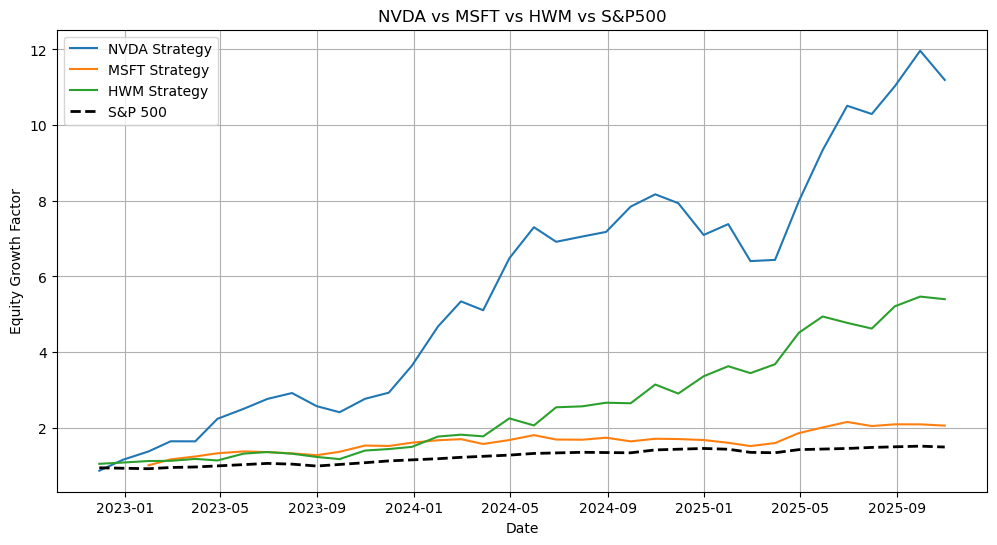

In [30]:
#Example equitychart

def plot_multi_equity(df_monthly_bt, symbols, title="Multi-Stock Backtest"):
    plt.figure(figsize=(12, 6))

    # Plot each stock equity curve
    for sym in symbols:
        g = df_monthly_bt[df_monthly_bt["symbol"] == sym].dropna(subset=["fwd_return_1m"])
        if g.empty: 
            continue
        g = g.sort_values("date")
        g["equity_stock"] = (1 + g["fwd_return_1m"]).cumprod()
        plt.plot(g["date"], g["equity_stock"], label=f"{sym} Strategy")

    # Plot S&P 500 once
    sp = df_monthly_bt.drop_duplicates("date").dropna(subset=["fwd_sp500_return_1m"])
    sp = sp.sort_values("date")
    sp["equity_sp500"] = (1 + sp["fwd_sp500_return_1m"]).cumprod()
    plt.plot(sp["date"], sp["equity_sp500"], label="S&P 500", color="black", linestyle="--", linewidth=2)

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity Growth Factor")
    plt.grid(True)
    plt.legend()
    plt.show()

# Example: Plot 3 tickers
plot_multi_equity(df_monthly_bt, ["NVDA", "MSFT", "HWM"], title="NVDA vs MSFT vs HWM vs S&P500")

**EDA for all stock vs SP500 Backtest**

In [ ]:
# Load backtest outputs for chart
bt_ts = pd.read_csv("./data/backtest_time_series.csv", parse_dates=["date"])
bt_stock = pd.read_csv("./data/backtest_per_symbol.csv")

**Strategy vs S&P 500 Performance**

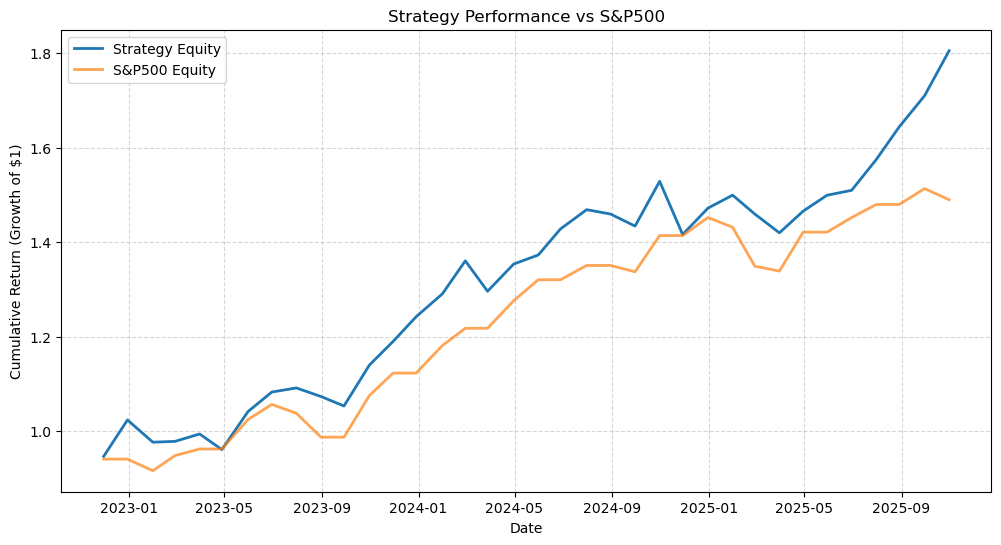

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(bt_ts["date"], bt_ts["strategy_equity"], label="Strategy Equity", linewidth=2)
plt.plot(bt_ts["date"], bt_ts["sp500_equity"], label="S&P500 Equity", linewidth=2, alpha=0.7)

plt.title("Strategy Performance vs S&P500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Growth of $1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



We compare overall strategy equity in term of if we invest all stocks compare with S&P 500 index. Majority of the time the return is outperform S&P500

###  Quantamental Model Output Explanation

The table below explains each column from the final Quantamental model output.  
This output combines predictions from the **Random Forest ML model**, **Hybrid Score** (Fundamental + Technical blend), and **key financial indicators** to provide a complete view of each stock’s expected performance.

| **Column Name** | **Description** | **Interpretation / Purpose** |
|------------------|------------------|-------------------------------|
| **symbol** | Stock ticker symbol | Identifies the company (e.g., AAPL, GM, ISRG). |
| **pred_prob_next_month** | Predicted probability of outperforming the S&P 500 next month | Higher value = higher likelihood to beat the market. |
| **signal** | Model-based trading signal | Categorized as **LONG-Outperform**, **SHORT-Underperform**, or **NEUTRAL**, based on cutoff thresholds. |
| **Hybrid_Score** | Combined weighted score from fundamental and technical signals | Represents overall stock strength. Higher = stronger combined outlook. |
| **Fundamental_Score** | Score based only on company fundamentals | Reflects long-term financial health, profitability, and balance sheet strength. |
| **Technical_Score** | Score based only on recent price and momentum trends | Reflects short-term market behavior and trading sentiment. |
| **Hybrid_Rank** | Rank position among all stocks based on Hybrid_Score | Lower number = higher overall rank. |
| **Hybrid_CS_Pct** | Percentile score of the Hybrid Score | Measures how strong the stock is relative to all others (0–1 scale). |
| **H_Score Recommendation** | Interpreted signal combining ML and Hybrid outputs | Example: “Short-Term Buy (Momentum)” or “Avoid / Bearish.” Indicates whether stock is suitable for trading or long-term holding. |
| **date** | Date of snapshot (last trading day of the month) | Represents the data point used for prediction (e.g., October 2025). |

---

###  Key Financial Ratios (Fundamentals)

| **Feature** | **Meaning** | **Why It Matters** |
|--------------|--------------|---------------------|
| **roe** | Return on Equity | Profitability relative to shareholders’ equity. Higher = more efficient use of capital. |
| **roic** | Return on Invested Capital | Measures how effectively a company uses all capital (debt + equity). |
| **peRatio** | Price-to-Earnings ratio | Valuation metric. High PE can indicate growth expectations; low PE may signal undervaluation. |
| **freeCashFlowYield** | Free Cash Flow ÷ Market Cap | Measures how much cash a company generates relative to its value — higher is better. |
| **debtToEquity** | Total debt ÷ shareholders’ equity | Leverage indicator — higher values mean more debt risk. |
| **currentRatio** | Current assets ÷ current liabilities | Liquidity measure — ability to cover short-term obligations. |
| **dividendYield** | Dividend ÷ stock price | Measures shareholder income return. Useful for defensive, income-focused investors. |
| **earningsYield** | Earnings ÷ stock price | Inverse of PE — compares profitability to market valuation. |
| **payoutRatio** | Dividends ÷ earnings | Shows what percentage of profit is paid out as dividends. |
| **cashPerShare** | Total cash ÷ shares outstanding | Indicates liquidity strength. |
| **revenuePerShare** | Revenue ÷ shares outstanding | Shows top-line efficiency on a per-share basis. |

---

###  Technical Indicators

| **Feature** | **Meaning** | **Interpretation** |
|--------------|-------------|--------------------|
| **return_1m** | 1-month % price change | Measures short-term momentum. |
| **ema_12 / ema_26** | 12-day and 26-day exponential moving averages | Smooths price trends to identify direction. |
| **macd** | EMA(12) – EMA(26) | Trend strength — positive = bullish, negative = bearish. |
| **macd_signal / macd_hist** | MACD smoothing and histogram | Helps detect trend reversals. |
| **RSI_14** | Relative Strength Index (14 days) | <30 = oversold (potential buy), >70 = overbought (potential sell). |
| **volatility_21d** | 21-day rolling standard deviation of returns | Measures market risk — higher = more unstable. |

---

###  How to Interpret the Output
- **High pred_prob_next_month + High Hybrid_Score** → Strong outperformer candidate.  
- **High Fundamental_Score + Moderate Technical_Score** → Long-term stable investment.  
- **High Technical_Score + Low Fundamental_Score** → Short-term momentum trade.  
- **Low scores across all factors** → Likely underperformer or “Avoid” signal.

---



### Pipeline Execution ###

The code in this notebook will be used to create python script , create docker contain and create the ML pipeline to make it locally run prior to deploy in GCP.

The quantamental pipeline is orchestrated through `main.py`, which executes a 7-step 
workflow: (1) data collection from the FMP API, (2) feature engineering with 30+ 
technical and fundamental indicators, (3) model training using Random Forest 
classification, (4) model validation against quality thresholds (35% minimum, 80% 
production), (5) prediction and backtesting with hybrid scoring, (6) optional RAG 
reasoning via ChromaDB and Vertex AI, and (7) data versioning through W&B Artifacts. 

Currently, the pipeline is executed manually via `python main.py`, while GitHub 
Actions handles continuous integration (automated testing and linting on each push). 
All training runs, metrics, and model artifacts are logged to Weights & Biases for 
experiment tracking and reproducibility.

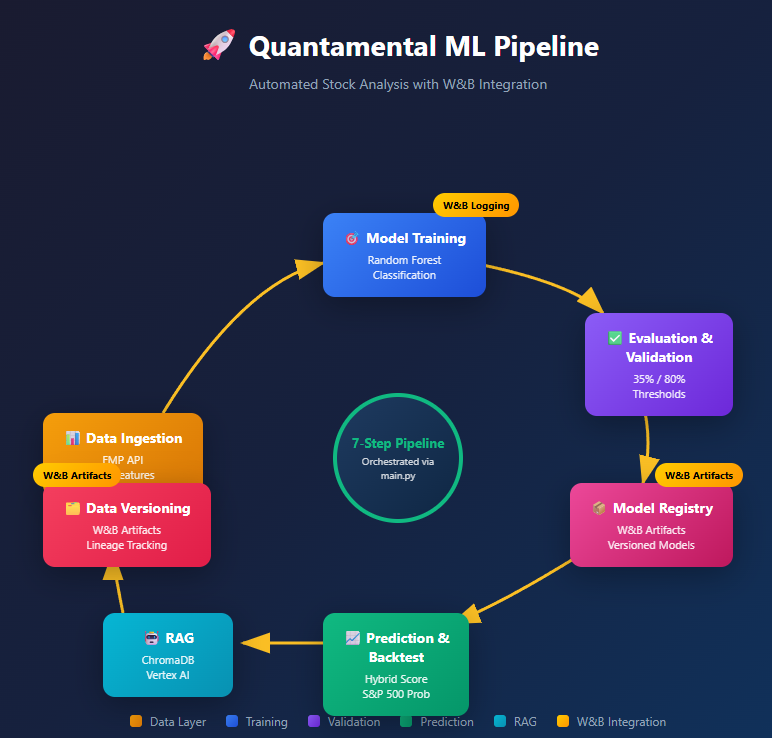

## Future deployment :GCP Automation ##

In MS5 involves deploying the pipeline to **Google Cloud Platform** for fully 
automated execution:

1. **Containerization**: Package the 7-step pipeline into a Docker container
2. **Cloud Run Deployment**: Deploy as a serverless container service
3. **Cloud Scheduler**: Trigger monthly retraining (1st of each month)
4. **Integration Points**:
   - **Cloud Storage**: Store raw data, processed features, and model outputs
   - **Vertex AI**: Power RAG reasoning with Gemini models
   - **Secret Manager**: Secure storage for API keys (FMP, W&B)
   - **Cloud Build**: Automated deployment on code changes

This architecture ensures the model stays current with market conditions while maintaining 
full reproducibility through W&B experiment tracking.

---